In [95]:
import pandas as pd
import numpy as np
from itables import init_notebook_mode
import polars as pl
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

init_notebook_mode(all_interactive=True)
from matplotlib.patches import Patch
import polars as pl
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

In [2]:
import sys
sys.path.append("/home/a379i/Scripts")   # path to folder containing the python file

from utils.load_gtf_cgc_dresden import *
from ProteinExpression.load_pr_data import *


/home/a379i/Scripts/utils/load_gtf_cgc_dresden.py:106: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Extended predisp' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  cgc.loc[cgc["geneID_short"].isin(extended_dresden_dt["geneID_short"]), "Predisposition"] = "Extended predisp"
/home/a379i/Scripts/utils/load_gtf_cgc_dresden.py:111: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Extended predisp' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  extended_dresden_dt_cgc.loc[extended_dresden_dt_cgc["geneID_short"].isin(extended_dresden_dt["geneID_short"]), "Predisposition"] = "Extended predisp"


In [383]:
def create_fisher_dt(
    aberrant_dt,
    expression_direction,
    gene_list,
    omics_type="PROTRIDER",
    cluster_col="Diag"
):

    if omics_type == "PROTRIDER":
        omic_id = "proteinID"
        zscore_col = "zScore"
        outlier_col = "aberrant"
    elif omics_type in ["OUTRIDER", "Activation"]:
        omic_id = "geneID"
        zscore_col = "zScore"
        outlier_col = "aberrant"
    elif omics_type == "FRASER":
        outlier_col = "aberrant"
        omic_id = "hgncSymbol"
        zscore_col = None
    else:
        raise ValueError("Unknown omics_type")

    df = aberrant_dt[aberrant_dt[omic_id].isin(gene_list)].copy()

    if zscore_col is not None:
        if expression_direction == "Underexpression":
            df = df[df[zscore_col] < 0]
        elif expression_direction == "Overexpression":
            df = df[df[zscore_col] > 0]

    # rename columns
    df = df.rename(columns={
        omic_id: "proteinID",
        cluster_col: "cluster_column"
    })

    # ---------------------------------------------------------
    # A: aberrant samples per gene and disease
    # ---------------------------------------------------------
    A_counts = (
        df[df[outlier_col] == True]
        .groupby(["proteinID", "cluster_column"])["sampleID"]
        .nunique()
        .reset_index(name="A")
    )

    # ---------------------------------------------------------
    # total samples per disease
    # ---------------------------------------------------------
    total_samples_per_disease = (
        df.groupby("cluster_column")["sampleID"]
        .nunique()
        .reset_index(name="TotalSamplesInDisease")
    )

    # ---------------------------------------------------------
    # full grid
    # ---------------------------------------------------------
    all_gene_disease = (
        pd.MultiIndex.from_product(
            [df["proteinID"].unique(),
             df["cluster_column"].unique()],
            names=["proteinID", "cluster_column"]
        )
        .to_frame(index=False)
    )

    plot_data = all_gene_disease.merge(
        A_counts,
        on=["proteinID", "cluster_column"],
        how="left"
    )

    plot_data["A"] = plot_data["A"].fillna(0).astype(int)

    plot_data = plot_data.merge(
        total_samples_per_disease,
        on="cluster_column",
        how="left"
    )

    # ---------------------------------------------------------
    # B
    # ---------------------------------------------------------
    plot_data["B"] = plot_data["TotalSamplesInDisease"] - plot_data["A"]

    # ---------------------------------------------------------
    # total aberrant per gene (overall)
    # ---------------------------------------------------------
    total_aberrant_gene_counts = (
        df[df[outlier_col] == True]
        .groupby("proteinID")["sampleID"]
        .nunique()
        .reset_index(name="TotalAberrantGeneOverall")
    )

    plot_data = plot_data.merge(
        total_aberrant_gene_counts,
        on="proteinID",
        how="left"
    )

    plot_data["TotalAberrantGeneOverall"] = (
        plot_data["TotalAberrantGeneOverall"].fillna(0).astype(int)
    )

    # ---------------------------------------------------------
    # C
    # ---------------------------------------------------------
    plot_data["C"] = plot_data["TotalAberrantGeneOverall"] - plot_data["A"]

    # ---------------------------------------------------------
    # total samples overall per gene
    # ---------------------------------------------------------
    total_samples_overall_per_gene = (
        df.groupby("proteinID")["sampleID"]
        .nunique()
        .reset_index(name="TotalGeneSamplesOverall")
    )

    plot_data = plot_data.merge(
        total_samples_overall_per_gene,
        on="proteinID",
        how="left"
    )

    # ---------------------------------------------------------
    # samples in disease for gene
    # ---------------------------------------------------------
    samples_in_disease_for_gene = (
        df.groupby(["proteinID", "cluster_column"])["sampleID"]
        .nunique()
        .reset_index(name="SamplesInDiseaseForGene")
    )

    plot_data = plot_data.merge(
        samples_in_disease_for_gene,
        on=["proteinID", "cluster_column"],
        how="left"
    )

    plot_data["SamplesInDiseaseForGene"] = (
        plot_data["SamplesInDiseaseForGene"].fillna(0).astype(int)
    )

    # ---------------------------------------------------------
    # D
    # ---------------------------------------------------------
    plot_data["D"] = (
        (plot_data["TotalGeneSamplesOverall"]
         - plot_data["SamplesInDiseaseForGene"])
        - plot_data["C"]
    )

    # ---------------------------------------------------------
    # Odds ratio
    # ---------------------------------------------------------
    eps = 0.01

    or_val = (
        ((plot_data["A"] + eps) / (plot_data["B"] + eps)) /
        ((plot_data["C"] + eps) / (plot_data["D"] + eps))
    )

    or_val = or_val.replace([np.inf, -np.inf], np.nan)

    plot_data["odds_ratio"] = or_val
    plot_data.loc[plot_data["odds_ratio"] < 1, "odds_ratio"] = 0

    return plot_data


def prepare_plot_data(plot_data):

    # breaks: c(0,1,10,100,1000,Inf)
    bins = [0, 1, 10, 100, 1000, np.inf]
    labels = ["1", "1-10", "10-100", "100-1000", "ge1000"]

    plot_data = plot_data.copy()

    plot_data["odds_ratio_category"] = pd.cut(
        plot_data["odds_ratio"],
        bins=bins,
        labels=labels,
        right=False,
        include_lowest=True
    )

    plot_data = plot_data[
        plot_data["cluster_column"].notna() &
        plot_data["proteinID"].notna()
    ]

    odds_ratio_matrix = (
        plot_data
        .pivot_table(
            index="cluster_column",
            columns="proteinID",
            values="odds_ratio",
            aggfunc="first"
        )
        .fillna(0)
    )

    return odds_ratio_matrix


# Fill NA with 'unknown'
role_data = cgc[["gene_name", "ROLE_IN_CANCER"]].copy()
role_data["ROLE_IN_CANCER"] = role_data["ROLE_IN_CANCER"].fillna("unknown")

# Create a mapping of gene -> role
role_mapping = role_data.set_index("gene_name")["ROLE_IN_CANCER"]

role_palette = {
    "TSG": "#3498db",        # Blue
    "oncogene": "#e74c3c",   # Red
    "fusion": "#2ecc71",     # Green
    "oncogene, TSG": "orange",
    "oncogene, fusion": "yellow",
    "TSG, fusion": "lightblue",
    "oncogene, TSG, fusion": "#ff8282", # light red
    "unknown": "#bdc3c7"     # Grey
}

predisposition_palette = {"Predisposition": "red", "Extended predisp": "blue"}
# Fill NA with 'unknown'
predisp_role_data = extended_dresden_dt_cgc[["gene_name", "Predisposition"]].copy()
predisp_role_data["Predisposition"] = predisp_role_data["Predisposition"].fillna("unknown")

# Create a mapping of gene -> role
predisp_role_mapping = predisp_role_data.set_index("gene_name")["Predisposition"]

# Assuming dresden_dt_cgc contains both columns
meta_data = cgc[["gene_name", "ROLE_IN_CANCER", "Predisposition"]].copy()
meta_data_2 = extended_dresden_dt_cgc[["gene_name", "ROLE_IN_CANCER", "Predisposition"]].copy()

meta_data = pd.concat((meta_data, meta_data_2)).reset_index()
meta_data = meta_data.drop_duplicates(subset=["gene_name"])
meta_data["index"] = [i for i in range(len(meta_data))]

meta_data["ROLE_IN_CANCER"] = meta_data["ROLE_IN_CANCER"].fillna("unknown")
meta_data["Predisposition"] = meta_data["Predisposition"].fillna("unknown")


In [67]:
rna_sa = pd.read_csv(
    "/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/sample_data/master_drop_sample_annotation_sizeFactorFiltered_0.1.tsv",
    sep="\t"
)
suff_cohorts = rna_sa["Oncotree Code"].value_counts()[:130].index # at least 10 samples per cohort



Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [36]:
def plot_heatmap(odds_ratio_matrix, xlabel, title, ylabel="Diag", xfont_size=6, yfont_size=6):

    # 1. Define the color palette and force it to be smooth
    colors = ["#FFFFFF", "#D9D1E8", "#A38ECF", "#6D4FB6", "#441E7F"]
    # N=256 ensures a smooth gradient instead of discrete bands
    cmap = mcolors.LinearSegmentedColormap.from_list("CustomSmooth", colors, N=256)
    
    # 2. Create the clustermap
    g = sns.clustermap(
        odds_ratio_matrix,
        cmap=cmap,
        # Continuous log scale from 1 to 100
        norm=mcolors.LogNorm(vmin=1, vmax=100), 
        col_colors=col_colors,  # <--- Add the role color bar here
        figsize=(10, 10),
        xticklabels=True,
        yticklabels=True,
        row_cluster=True,
        col_cluster=True
    )
    
    g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xmajorticklabels(), fontsize = xfont_size)
    g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_ymajorticklabels(), fontsize = yfont_size)
    
    # 3. Titles and Labels
    g.ax_heatmap.set_ylabel(ylabel)
    g.ax_heatmap.set_xlabel(xlabel)
    g.fig.suptitle(title)
    
    # 4. Format the Colorbar
    colorbar = g.ax_heatmap.collections[0].colorbar
    colorbar.set_ticks([1, 10, 100])
    colorbar.set_ticklabels(["1", "10", "≥100"])
    
    # REMOVE TICKS: This hides the small lines next to the numbers
    colorbar.ax.tick_params(size=0) 
    
    colorbar.ax.set_title("Odds ratio", pad=10, fontsize=10, weight='bold')
    
    
    # ---------------------------------------------------------
    # 5. Add Two Separate Legends
    # ---------------------------------------------------------
    # Legend for Role
    legend1 = [Patch(facecolor=c, label=l) for l, c in role_palette.items() if l in meta_mapping["ROLE_IN_CANCER"].unique()]
    # Legend for Predisposition
    legend2 = [Patch(facecolor=c, label=l) for l, c in predisposition_palette.items() if l in meta_mapping["Predisposition"].unique()]
    
    # Add first legend
    l1 = g.fig.legend(handles=legend1, title="Gene Role", loc='upper right', bbox_to_anchor=(1.1, 1.1))
    # Add second legend (must use ax.add_artist to prevent it from overwriting the first)
    l2 = g.fig.legend(handles=legend2, title="Predisposition", loc='upper right', bbox_to_anchor=(1.1, 0.95))
    g.fig.add_artist(l1)
    
    # 3. Re-add l1 to the figure
    g.fig.add_artist(l1)
    
    plt.show()

In [14]:
or_res

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [19]:
or_res = pl.read_parquet(
    "/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/py_outrider_runs/all_cohorts/oht_cov_diag_lr_0_0001_epoc200_gpu/or_variants_predisppadjust.parquet",
    columns= ["sampleID", "geneID_short", "zScore", "padjust", "padjust_predisp_extended", "padjust_predisp"]
)
or_res = or_res.to_pandas()

or_res.loc[or_res["padjust_predisp_extended"] <= 0.05, "aberrant"] = True



or_res = or_res.merge(
    rna_sa[[
        "pid", "Oncotree Code", "SEX", "ICD10 Code",
        "TISSUE", "Tumorzellgehalt (Bioinformatik)", "Diag"
    ]],
    left_on="sampleID",
    right_on="pid",
    how="left"
)

or_res = or_res.merge(
    gene_annot_dt[["geneID_short", "gene_name", "gene_type"]],
    on="geneID_short",
    how="left"
)

or_res = or_res.rename(columns={
    "gene_name": "geneID"
})


In [71]:
or_dt[or_dt["row_name"].isin(suff_cohorts)]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [26]:
# or_res[(or_res["Oncotree Code"] == "ES") & (or_res["padjust"] <= 0.05) & (or_res["geneID"] == "SH2B3")] # 2 significant
# or_res[(or_res["Oncotree Code"] == "GIST") & (or_res["padjust"] <= 0.05) & (or_res["geneID"] == "SDHB")] # 
# or_res[(or_res["Oncotree Code"] == "SYNS") & (or_res["padjust"] <= 0.05) & (or_res["geneID"] == "RUNX1T1")] # 2 significnat
or_res[(or_res["Oncotree Code"] == "PECOMA") & (or_res["aberrant"] == True) & (or_res["geneID"] == "TSC2")] # 4 significant in ASPS, 10 in total
# or_res[(or_res["Oncotree Code"] == "LGSOC") & (or_res["padjust"] <= 0.05) & (or_res["geneID"] == "BCL10")] # 1 significant



Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


## enrichment per Oncotree 

In [68]:
plot_data = create_fisher_dt(
    or_res,
    "Underexpression",
    extended_dresden_dt_cgc["gene_name"],
    omics_type="OUTRIDER",
    cluster_col="Oncotree Code"
)

plot_data = plot_data[plot_data["TotalAberrantGeneOverall"] > 1]
plot_data = plot_data[plot_data["A"] > 2]
plot_data.loc[plot_data["A"] == 0, "odds_ratio"] = 0
plot_data["proportion"] = plot_data["A"]/plot_data["TotalSamplesInDisease"]


odds_ratio_matrix = prepare_plot_data(plot_data)

# drop empty columns
odds_ratio_matrix = odds_ratio_matrix.loc[
    :, odds_ratio_matrix.sum(axis=0) != 0
]

# ------------------------------------------------------------
# extract significant entries
# ------------------------------------------------------------

idx = np.where(odds_ratio_matrix.values >= 1)

or_dt = pd.DataFrame({
    "row_name": odds_ratio_matrix.index[idx[0]],
    "col_name": odds_ratio_matrix.columns[idx[1]],
    "odds_pr_overexpression": odds_ratio_matrix.values[idx]
})

or_dt["gene_cancer"] = (
    or_dt["row_name"].astype(str) + "_" +
    or_dt["col_name"].astype(str)
)

or_dt = or_dt.sort_values(
    "odds_pr_overexpression",
    ascending=False
)

genes_of_interest = np.union1d(
    or_dt.iloc[:30]["col_name"].values,
    cgc_tsg["gene_name"].values
)


k = 50
topk_genes = (
    or_dt
    .groupby("col_name")["odds_pr_overexpression"]
    .max()
    .sort_values(ascending=False)
    .head(k)
    .index
)

odds_ratio_matrix = odds_ratio_matrix.loc[list(set(suff_cohorts).intersection(set(odds_ratio_matrix.index)))]
odds_ratio_matrix = odds_ratio_matrix.loc[odds_ratio_matrix.sum(axis=1) > 2]

odds_ratio_matrix_topk = odds_ratio_matrix.loc[
    :, odds_ratio_matrix.columns.intersection(list(topk_genes))
]

# Set index to gene_name and reindex to match the matrix columns exactly
meta_mapping = meta_data.set_index("gene_name").reindex(odds_ratio_matrix_topk.columns).fillna("unknown")



# ---------------------------------------------------------
# 3. Create the Color DataFrame
# ---------------------------------------------------------
# Map the values to colors
col_colors = pd.DataFrame(index=meta_mapping.index)
col_colors["Role"] = meta_mapping["ROLE_IN_CANCER"].map(lambda x: role_palette.get(x, "#bdc3c7"))
col_colors["Predisposition"] = meta_mapping["Predisposition"].map(lambda x: predisposition_palette.get(x, "#7f8c8d"))

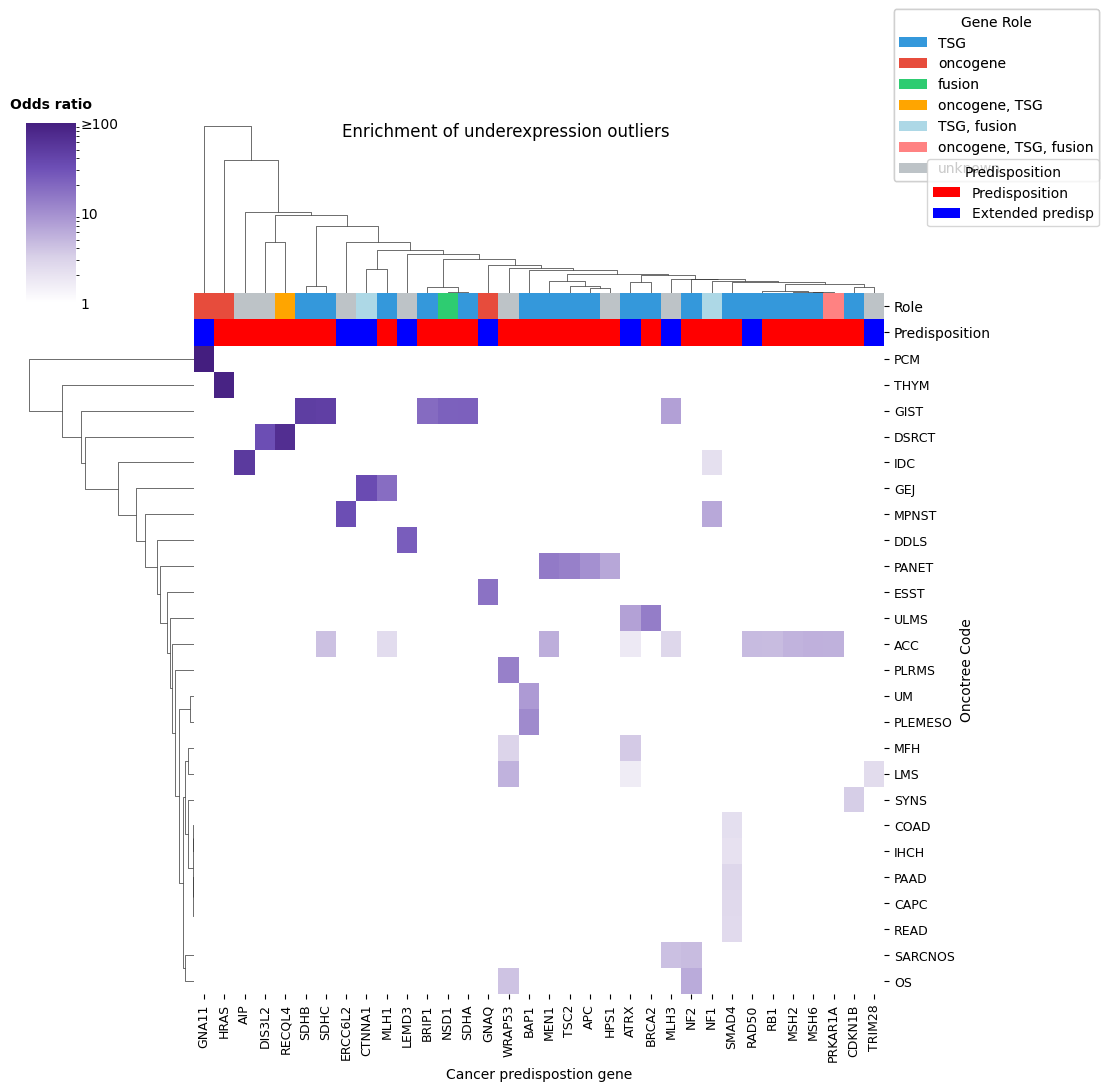

In [69]:
plot_heatmap(odds_ratio_matrix_topk, "Cancer predispostion gene", "Enrichment of underexpression outliers", ylabel="Oncotree Code", yfont_size=9, xfont_size=9)

In [89]:
or_dt

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [ ]:
def get_significance_stars(p):
    if p < 0.0001: return '****'
    if p < 0.001:  return '***'
    if p < 0.01:   return '**'
    if p < 0.05:   return '*'
    return 'ns'


In [449]:
def create_proportions_per_entity(or_res, gene_lists, expression_direction="Underexpression", id_col="geneID", keep_sig = True, sa=None):
    
    plot_dt = []
    for gene_interest in gene_lists:
        # 1. Filter ONLY for the gene. Keep all z-scores for now.
        df_gene = or_res[or_res[id_col] == gene_interest].copy()
        
        # 2. Define your "Success" condition (The Numerator)
        # A sample is truly 'activated/underexpressed' ONLY if it is aberrant AND zScore < 0
        if expression_direction == "Underexpression":
            df_gene['is_active'] = (df_gene['aberrant'] == True) & (df_gene['zScore'] < 0)
        elif expression_direction == "Overexpression":
            df_gene['is_active'] = (df_gene['aberrant'] == True) & (df_gene['zScore'] > 0)
        elif expression_direction == "Splicing":
            df_gene['is_active'] = (df_gene['aberrant'] == True)
        
        # 3. Aggregate
        results = []
        all_diseases = sa['Oncotree Code'].unique()
        
        for disease in all_diseases:
            in_cohort = df_gene[df_gene['Oncotree Code'] == disease]
            out_cohort = df_gene[df_gene['Oncotree Code'] != disease]
            
            # Numerator: count of samples meeting the 'is_active' criteria
            a = in_cohort['is_active'].sum()
            # Denominator: TOTAL samples in that cohort
            
            total_in = len(in_cohort) 
            total_in = len(sa[sa["Oncotree Code"] == disease])

            
            b = out_cohort['is_active'].sum()
            total_out = len(out_cohort)
            
            total_out = len(sa[sa["Oncotree Code"] != disease])

            
            # Fisher Test: [[Success_In, Success_Out], [Fail_In, Fail_Out]]
            _, p_val = fisher_exact([[a, b], [total_in - a, total_out - b]], alternative='greater')
            
            results.append({
                'disease': disease,
                'activated': int(a),
                'total': total_in,
                'ratio': a / total_in if total_in > 0 else 0,
                'pval': p_val
            })
        
        stats_df = pd.DataFrame(results).sort_values('pval')
        
        if not stats_df.empty:
            _, p_adj, _, _ = multipletests(stats_df['pval'], method='fdr_bh')
            stats_df['padjust'] = p_adj
        else:
            stats_df['padjust'] = np.nan
        
        stats_df['stars'] = stats_df['padjust'].apply(get_significance_stars)
        if len(stats_df[stats_df["padjust"] <= 0.05]) == 0 and keep_sig == True:
            continue
            
        
        # --- 3. Aggregate "Rest of Samples" ---
        
        # Keep top 3, group the rest
        top_3 = stats_df[stats_df["stars"] != "ns"]
        if len(top_3) < 3:
            top_3 = stats_df.iloc[:3]
        rest = stats_df.iloc[len(top_3):]
            
        if not rest.empty:
            combined_rest = pd.DataFrame([{
                    'disease': 'Others',
                    'activated': rest['activated'].sum(),
                    'total': rest['total'].sum(),
                    'ratio': rest['activated'].sum() / rest['total'].sum(),
                    'stars': 'ns' # Usually non-significant when aggregated
            }])
            plot_df = pd.concat([top_3, combined_rest])
        else:
            plot_df = top_3
        
        # Final formatting for labels
        plot_df['top_label'] = (plot_df['ratio']*100).round(1).astype(str) + "%\n(" + \
                               plot_df['activated'].astype(str) + "/" + plot_df['total'].astype(str) + ")"
        plot_df["gene_name"] = gene_interest
        plot_dt.append(plot_df)
    plot_dt = pd.concat(plot_dt)
    return plot_dt


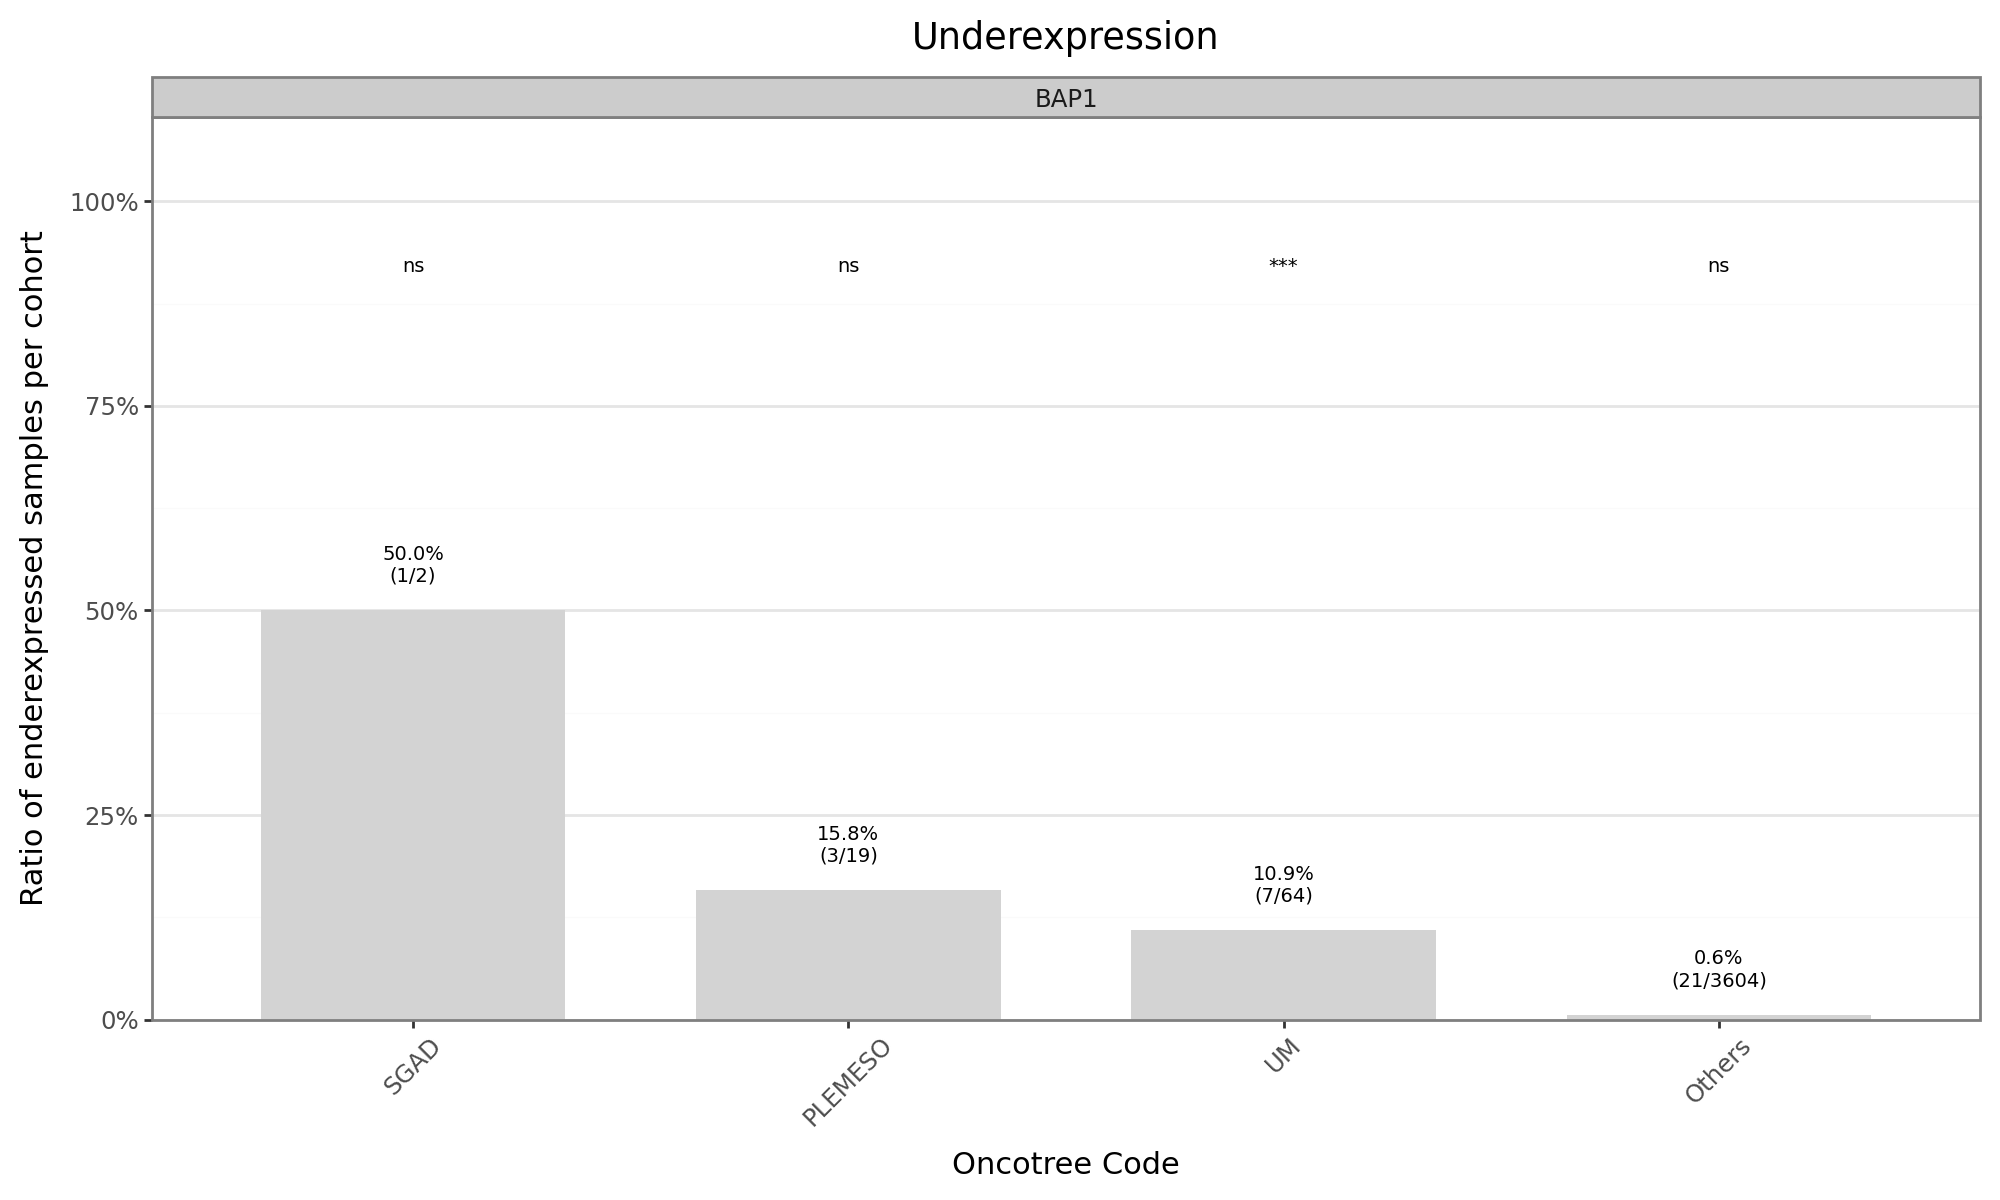

In [210]:
plot_dt = create_proportions_per_entity(or_res, ["BAP1"])
# Ensure the order is preserved (Top 1, 2, 3, then Others)
plot = (
    ggplot(plot_dt, aes(x='reorder(disease, -ratio)', y='ratio'))
    + facet_wrap("gene_name", scales="free_x", nrow=2)
    + geom_col(fill="#d3d3d3", width=0.7)
    + geom_text(aes(label='top_label'), va='bottom', nudge_y=0.03, size=7)
    + geom_text(aes(label='stars'), y=0.92, size=7)
    + scale_y_continuous(labels=lambda l: [f"{int(x*100)}%" for x in l],
                         limits=[0, 1.05],
                         expand=(0, 0, 0.05, 0)
                        )
    + labs(x="Oncotree Code", y=f"Ratio of enderexpressed samples per cohort", title=f"Underexpression")
    + theme_bw()
    + theme(panel_grid_major_x=element_blank(), axis_text_x=element_text(rotation=45), figure_size=(10, 6))
)

plot

In [204]:
plot_data = create_fisher_dt(
    or_res,
    "Overexpression",
    extended_dresden_dt_cgc["gene_name"],
    omics_type="OUTRIDER",
    cluster_col="Oncotree Code"
)

plot_data = plot_data[plot_data["TotalAberrantGeneOverall"] > 1]
plot_data = plot_data[plot_data["A"] > 2]
plot_data.loc[plot_data["A"] == 0, "odds_ratio"] = 0
plot_data["proportion"] = plot_data["A"]/plot_data["TotalSamplesInDisease"]


odds_ratio_matrix = prepare_plot_data(plot_data)

# drop empty columns
odds_ratio_matrix = odds_ratio_matrix.loc[
    :, odds_ratio_matrix.sum(axis=0) != 0
]

# ------------------------------------------------------------
# extract significant entries
# ------------------------------------------------------------

idx = np.where(odds_ratio_matrix.values >= 1)

or_dt = pd.DataFrame({
    "row_name": odds_ratio_matrix.index[idx[0]],
    "col_name": odds_ratio_matrix.columns[idx[1]],
    "odds_pr_overexpression": odds_ratio_matrix.values[idx]
})

or_dt["gene_cancer"] = (
    or_dt["row_name"].astype(str) + "_" +
    or_dt["col_name"].astype(str)
)

or_dt = or_dt.sort_values(
    "odds_pr_overexpression",
    ascending=False
)

genes_of_interest = np.union1d(
    or_dt.iloc[:30]["col_name"].values,
    cgc_tsg["gene_name"].values
)


k = 100
topk_genes = (
    or_dt
    .groupby("col_name")["odds_pr_overexpression"]
    .max()
    .sort_values(ascending=False)
    .head(k)
    .index
)

odds_ratio_matrix = odds_ratio_matrix.loc[list(set(suff_cohorts).intersection(set(odds_ratio_matrix.index)))]
odds_ratio_matrix = odds_ratio_matrix.loc[odds_ratio_matrix.sum(axis=1) > 2]

odds_ratio_matrix_topk = odds_ratio_matrix.loc[
    :, odds_ratio_matrix.columns.intersection(list(topk_genes))
]

# Set index to gene_name and reindex to match the matrix columns exactly
meta_mapping = meta_data.set_index("gene_name").reindex(odds_ratio_matrix_topk.columns).fillna("unknown")



# ---------------------------------------------------------
# 3. Create the Color DataFrame
# ---------------------------------------------------------
# Map the values to colors
col_colors = pd.DataFrame(index=meta_mapping.index)
col_colors["Role"] = meta_mapping["ROLE_IN_CANCER"].map(lambda x: role_palette.get(x, "#bdc3c7"))
col_colors["Predisposition"] = meta_mapping["Predisposition"].map(lambda x: predisposition_palette.get(x, "#7f8c8d"))

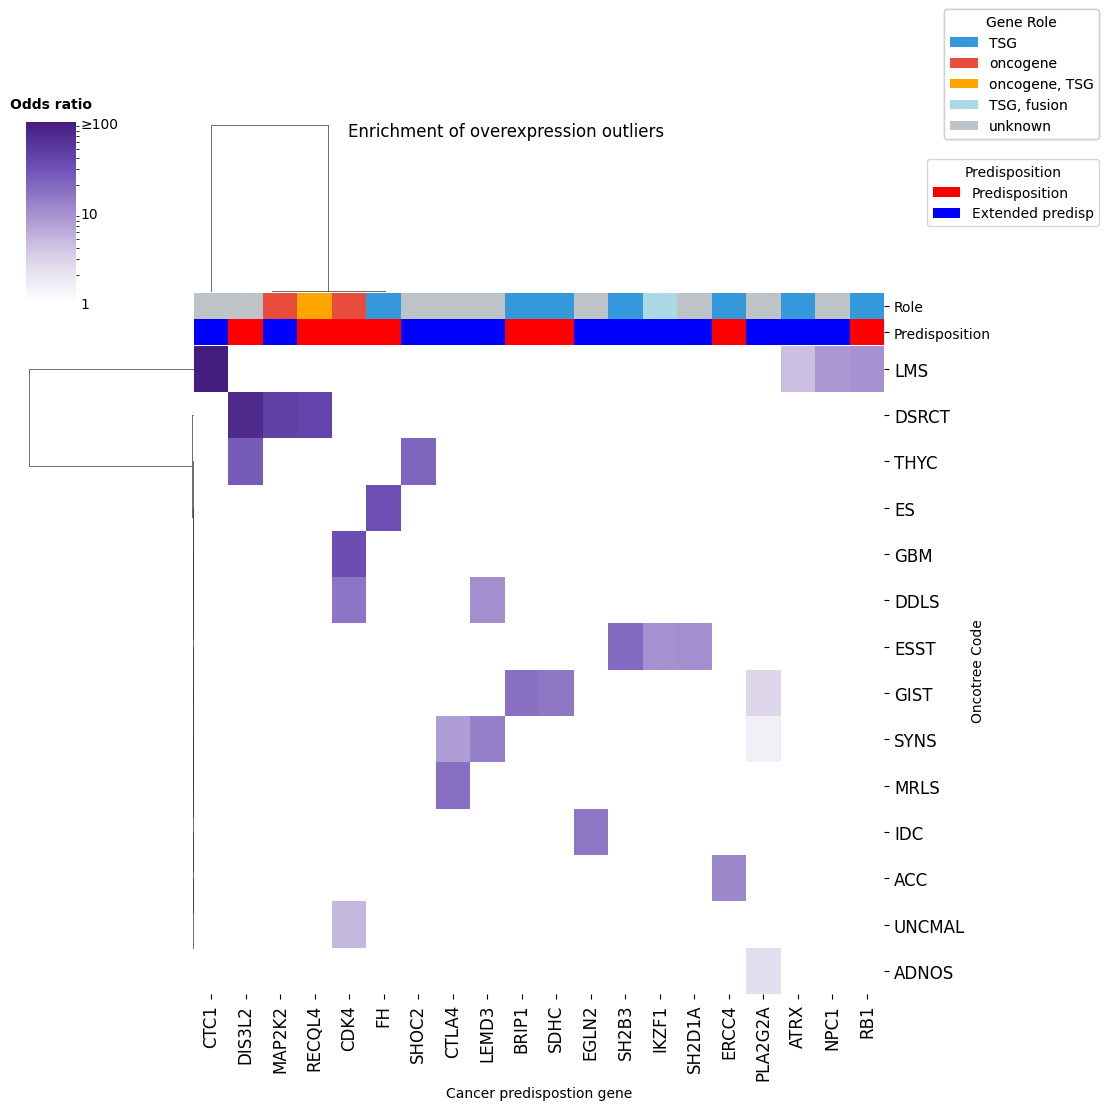

In [206]:
plot_heatmap(odds_ratio_matrix_topk, "Cancer predispostion gene", "Enrichment of overexpression outliers", ylabel="Oncotree Code", yfont_size=12, xfont_size=12)

In [223]:
over_expression_sorted_genes = or_dt["col_name"].unique()

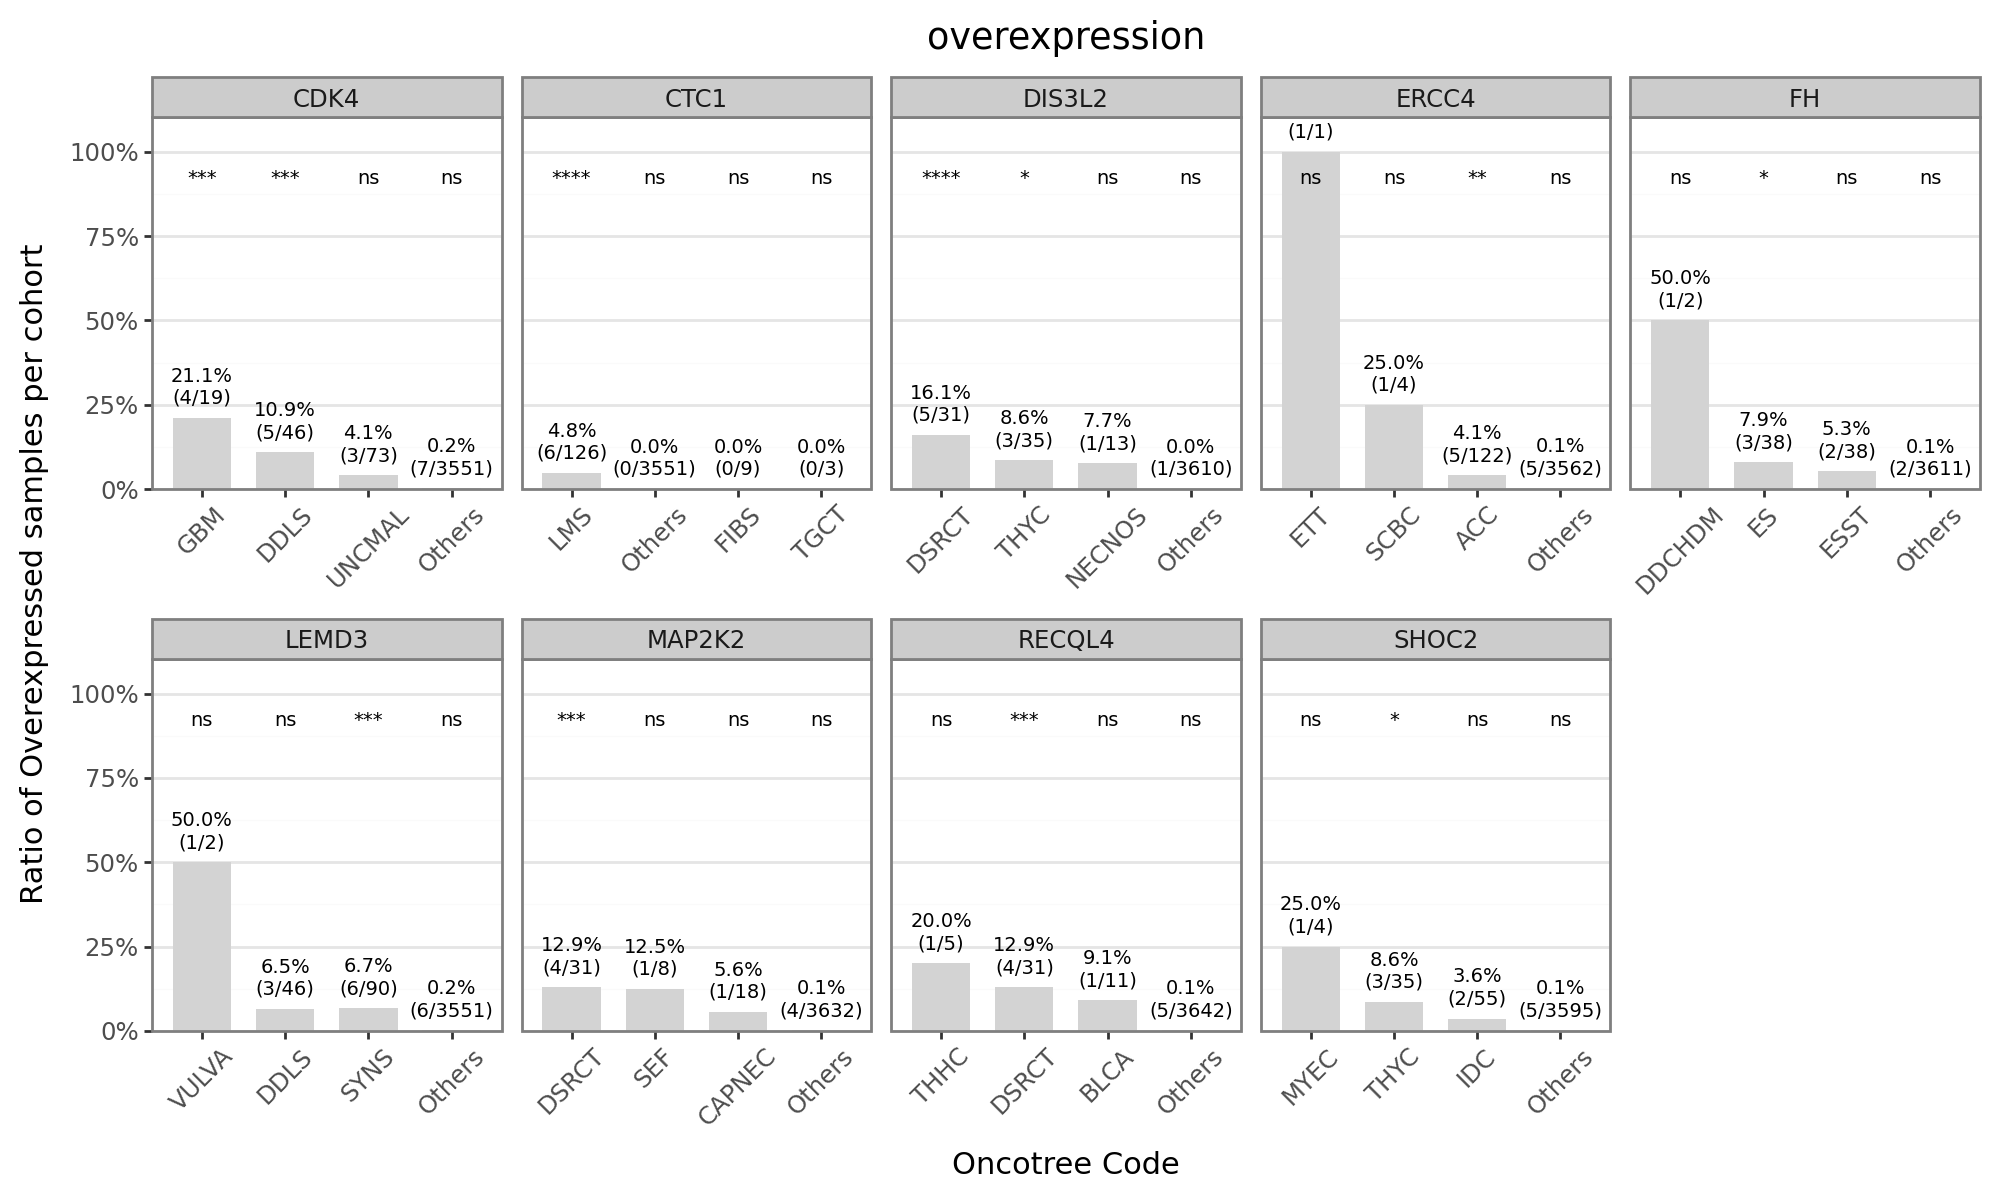

In [222]:
plot_dt = create_proportions_per_entity(or_res, over_expression_sorted_genes, "Overexpression")
# Ensure the order is preserved (Top 1, 2, 3, then Others)
plot = (
    ggplot(plot_dt, aes(x='reorder(disease, -ratio)', y='ratio'))
    + facet_wrap("gene_name", scales="free_x", nrow=2)
    + geom_col(fill="#d3d3d3", width=0.7)
    + geom_text(aes(label='top_label'), va='bottom', nudge_y=0.03, size=7)
    + geom_text(aes(label='stars'), y=0.92, size=7)
    + scale_y_continuous(labels=lambda l: [f"{int(x*100)}%" for x in l],
                         limits=[0, 1.05],
                         expand=(0, 0, 0.05, 0)
                        )
    + labs(x="Oncotree Code", y=f"Ratio of Overexpressed samples per cohort", title=f"overexpression")
    + theme_bw()
    + theme(panel_grid_major_x=element_blank(), axis_text_x=element_text(rotation=45), figure_size=(10, 6))
)

plot

# Gene Underexpression outliers

In [306]:
plot_data = create_fisher_dt(
    or_res,
    "Underexpression",
    cgc_tsg["gene_name"],
    omics_type="OUTRIDER"
)

plot_data = plot_data[plot_data["TotalAberrantGeneOverall"] > 1]
plot_data.loc[plot_data["A"] == 0, "odds_ratio"] = 0

odds_ratio_matrix = prepare_plot_data(plot_data)

# drop empty columns
odds_ratio_matrix = odds_ratio_matrix.loc[
    :, odds_ratio_matrix.sum(axis=0) != 0
]

# ------------------------------------------------------------
# extract significant entries
# ------------------------------------------------------------

idx = np.where(odds_ratio_matrix.values >= 1)

or_dt = pd.DataFrame({
    "row_name": odds_ratio_matrix.index[idx[0]],
    "col_name": odds_ratio_matrix.columns[idx[1]],
    "odds_pr_overexpression": odds_ratio_matrix.values[idx]
})

or_dt["gene_cancer"] = (
    or_dt["row_name"].astype(str) + "_" +
    or_dt["col_name"].astype(str)
)

or_dt = or_dt.sort_values(
    "odds_pr_overexpression",
    ascending=False
)

genes_of_interest = np.union1d(
    or_dt.iloc[:30]["col_name"].values,
    cgc_tsg["gene_name"].values
)


k = 50
topk_genes = (
    or_dt
    .groupby("col_name")["odds_pr_overexpression"]
    .max()
    .sort_values(ascending=False)
    .head(k)
    .index
)

odds_ratio_matrix_topk = odds_ratio_matrix.loc[
    :, odds_ratio_matrix.columns.intersection(list(topk_genes))
]

# Align roles with the current matrix columns (top50_genes)
# We use .reindex to ensure the order matches the heatmap columns exactly
gene_roles = role_mapping.reindex(odds_ratio_matrix_topk.columns).fillna("unknown")

# Define a color palette for the roles
# You can customize these hex codes as you like
unique_roles = gene_roles.unique()

# Ensure every role in your data has a color (fallback to grey if not in dict)
col_colors = gene_roles.map(lambda x: role_palette.get(x, "#bdc3c7"))


predisp_roles = predisp_role_mapping.reindex(odds_ratio_matrix_topk.columns).fillna("unknown")
unique_predisps = predisp_roles.unique()

# Ensure every role in your data has a color (fallback to grey if not in dict)
col_colors_predisp = predisp_roles.map(lambda x: predisposition_palette.get(x, "#bdc3c7"))


In [307]:


# Set index to gene_name and reindex to match the matrix columns exactly
meta_mapping = meta_data.set_index("gene_name").reindex(odds_ratio_matrix_topk.columns).fillna("unknown")



# ---------------------------------------------------------
# 3. Create the Color DataFrame
# ---------------------------------------------------------
# Map the values to colors
col_colors = pd.DataFrame(index=meta_mapping.index)
col_colors["Role"] = meta_mapping["ROLE_IN_CANCER"].map(lambda x: role_palette.get(x, "#bdc3c7"))
col_colors["Predisposition"] = meta_mapping["Predisposition"].map(lambda x: predisposition_palette.get(x, "#7f8c8d"))

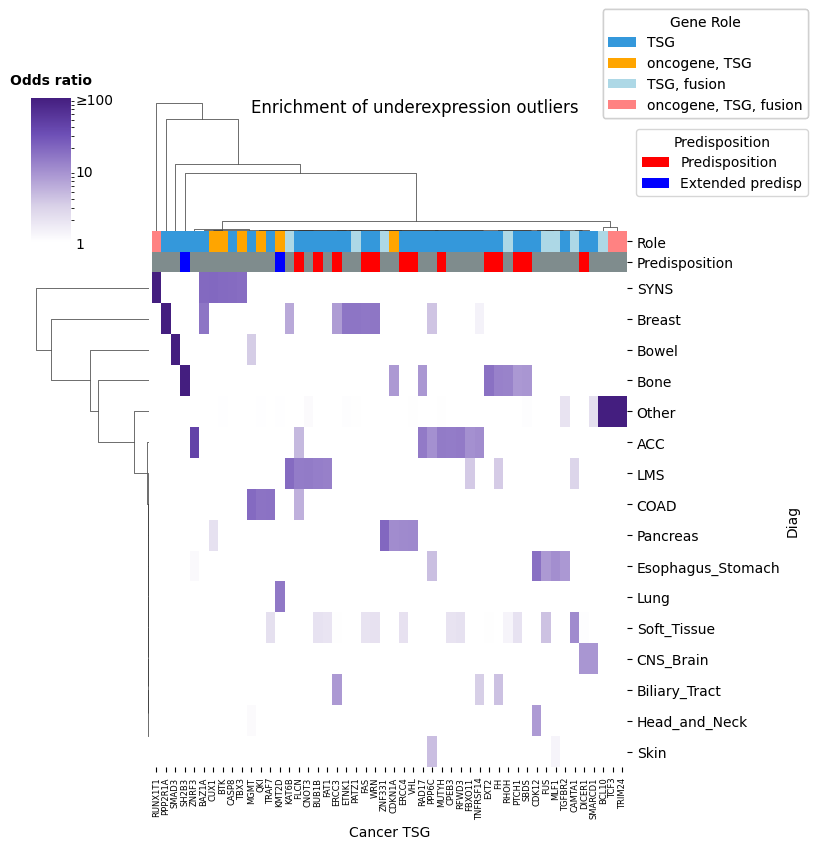

In [308]:
plot_heatmap(odds_ratio_matrix_topk, "Cancer TSG", "Enrichment of underexpression outliers")

In [312]:
plot_data = create_fisher_dt(
    or_res,
    "Underexpression",
    cgc["gene_name"],
    omics_type="OUTRIDER"
)

plot_data = plot_data[plot_data["TotalAberrantGeneOverall"] > 1]
plot_data.loc[plot_data["A"] == 0, "odds_ratio"] = 0

odds_ratio_matrix = prepare_plot_data(plot_data)

# drop empty columns
odds_ratio_matrix = odds_ratio_matrix.loc[
    :, odds_ratio_matrix.sum(axis=0) != 0
]

# ------------------------------------------------------------
# extract significant entries
# ------------------------------------------------------------

idx = np.where(odds_ratio_matrix.values >= 1)

or_dt = pd.DataFrame({
    "row_name": odds_ratio_matrix.index[idx[0]],
    "col_name": odds_ratio_matrix.columns[idx[1]],
    "odds_pr_overexpression": odds_ratio_matrix.values[idx]
})

or_dt["gene_cancer"] = (
    or_dt["row_name"].astype(str) + "_" +
    or_dt["col_name"].astype(str)
)

or_dt = or_dt.sort_values(
    "odds_pr_overexpression",
    ascending=False
)

genes_of_interest = np.union1d(
    or_dt.iloc[:30]["col_name"].values,
    cgc_tsg["gene_name"].values
)


k = 50
topk_genes = (
    or_dt
    .groupby("col_name")["odds_pr_overexpression"]
    .max()
    .sort_values(ascending=False)
    .head(k)
    .index
)

odds_ratio_matrix_topk = odds_ratio_matrix.loc[
    :, odds_ratio_matrix.columns.intersection(list(topk_genes))
]

# Align roles with the current matrix columns (top50_genes)
# We use .reindex to ensure the order matches the heatmap columns exactly
gene_roles = role_mapping.reindex(odds_ratio_matrix_topk.columns).fillna("unknown")

# Define a color palette for the roles
# You can customize these hex codes as you like
unique_roles = gene_roles.unique()

# Ensure every role in your data has a color (fallback to grey if not in dict)
col_colors = gene_roles.map(lambda x: role_palette.get(x, "#bdc3c7"))


predisp_roles = predisp_role_mapping.reindex(odds_ratio_matrix_topk.columns).fillna("unknown")
unique_predisps = predisp_roles.unique()

# Ensure every role in your data has a color (fallback to grey if not in dict)
col_colors_predisp = predisp_roles.map(lambda x: predisposition_palette.get(x, "#bdc3c7"))

# Assuming dresden_dt_cgc contains both columns
meta_data = cgc[["gene_name", "ROLE_IN_CANCER", "Predisposition"]].copy()
meta_data["ROLE_IN_CANCER"] = meta_data["ROLE_IN_CANCER"].fillna("unknown")
meta_data["Predisposition"] = meta_data["Predisposition"].fillna("unknown")

# Set index to gene_name and reindex to match the matrix columns exactly
meta_mapping = meta_data.set_index("gene_name").reindex(odds_ratio_matrix_topk.columns).fillna("unknown")



# ---------------------------------------------------------
# 3. Create the Color DataFrame
# ---------------------------------------------------------
# Map the values to colors
col_colors = pd.DataFrame(index=meta_mapping.index)
col_colors["Role"] = meta_mapping["ROLE_IN_CANCER"].map(lambda x: role_palette.get(x, "#bdc3c7"))
col_colors["Predisposition"] = meta_mapping["Predisposition"].map(lambda x: predisposition_palette.get(x, "#7f8c8d"))

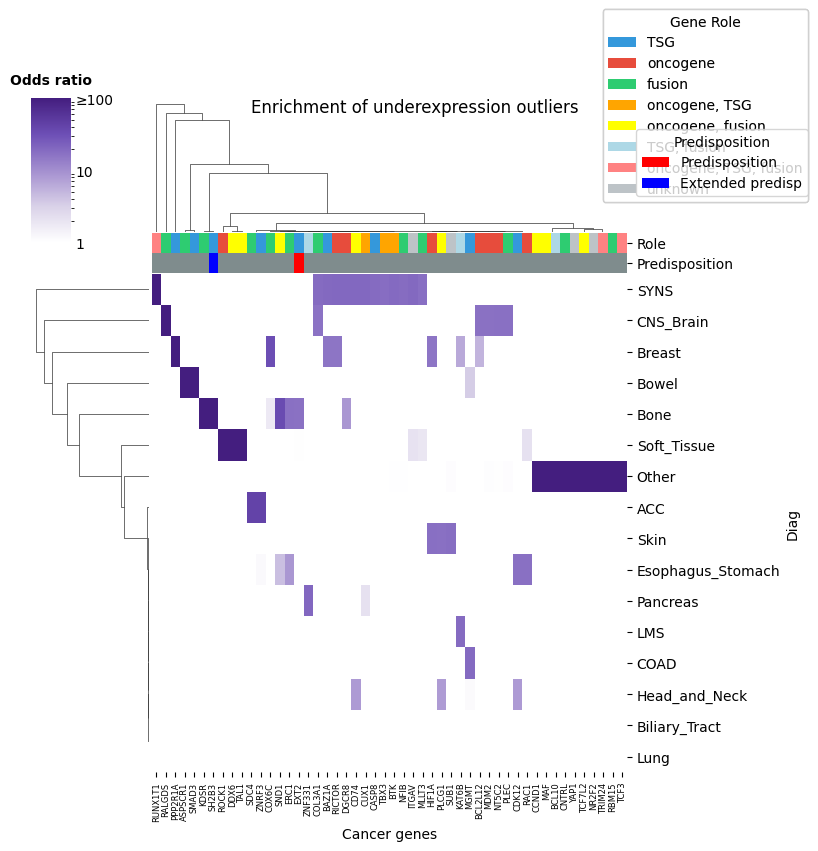

In [313]:
plot_heatmap(odds_ratio_matrix_topk, "Cancer genes", "Enrichment of underexpression outliers")

## gene overexpression

In [314]:
plot_data = create_fisher_dt(
    or_res,
    "Overexpression",
    cgc["gene_name"],
    omics_type="OUTRIDER"
)

plot_data = plot_data[plot_data["TotalAberrantGeneOverall"] > 1]
plot_data.loc[plot_data["A"] == 0, "odds_ratio"] = 0

odds_ratio_matrix = prepare_plot_data(plot_data)

# drop empty columns
odds_ratio_matrix = odds_ratio_matrix.loc[
    :, odds_ratio_matrix.sum(axis=0) != 0
]

# ------------------------------------------------------------
# extract significant entries
# ------------------------------------------------------------

idx = np.where(odds_ratio_matrix.values >= 1)

or_dt = pd.DataFrame({
    "row_name": odds_ratio_matrix.index[idx[0]],
    "col_name": odds_ratio_matrix.columns[idx[1]],
    "odds_pr_overexpression": odds_ratio_matrix.values[idx]
})

or_dt["gene_cancer"] = (
    or_dt["row_name"].astype(str) + "_" +
    or_dt["col_name"].astype(str)
)

or_dt = or_dt.sort_values(
    "odds_pr_overexpression",
    ascending=False
)

genes_of_interest = np.union1d(
    or_dt.iloc[:30]["col_name"].values,
    cgc_tsg["gene_name"].values
)


k = 50
topk_genes = (
    or_dt
    .groupby("col_name")["odds_pr_overexpression"]
    .max()
    .sort_values(ascending=False)
    .head(k)
    .index
)

odds_ratio_matrix_topk = odds_ratio_matrix.loc[
    :, odds_ratio_matrix.columns.intersection(list(topk_genes))
]

# Align roles with the current matrix columns (top50_genes)
# We use .reindex to ensure the order matches the heatmap columns exactly
gene_roles = role_mapping.reindex(odds_ratio_matrix_topk.columns).fillna("unknown")

# Define a color palette for the roles
# You can customize these hex codes as you like
unique_roles = gene_roles.unique()

# Ensure every role in your data has a color (fallback to grey if not in dict)
col_colors = gene_roles.map(lambda x: role_palette.get(x, "#bdc3c7"))


predisp_roles = predisp_role_mapping.reindex(odds_ratio_matrix_topk.columns).fillna("unknown")
unique_predisps = predisp_roles.unique()

# Ensure every role in your data has a color (fallback to grey if not in dict)
col_colors_predisp = predisp_roles.map(lambda x: predisposition_palette.get(x, "#bdc3c7"))

# Assuming dresden_dt_cgc contains both columns
meta_data = cgc[["gene_name", "ROLE_IN_CANCER", "Predisposition"]].copy()
meta_data["ROLE_IN_CANCER"] = meta_data["ROLE_IN_CANCER"].fillna("unknown")
meta_data["Predisposition"] = meta_data["Predisposition"].fillna("unknown")

# Set index to gene_name and reindex to match the matrix columns exactly
meta_mapping = meta_data.set_index("gene_name").reindex(odds_ratio_matrix_topk.columns).fillna("unknown")


# ---------------------------------------------------------
# 3. Create the Color DataFrame
# ---------------------------------------------------------
# Map the values to colors
col_colors = pd.DataFrame(index=meta_mapping.index)
col_colors["Role"] = meta_mapping["ROLE_IN_CANCER"].map(lambda x: role_palette.get(x, "#bdc3c7"))
col_colors["Predisposition"] = meta_mapping["Predisposition"].map(lambda x: predisposition_palette.get(x, "#7f8c8d"))

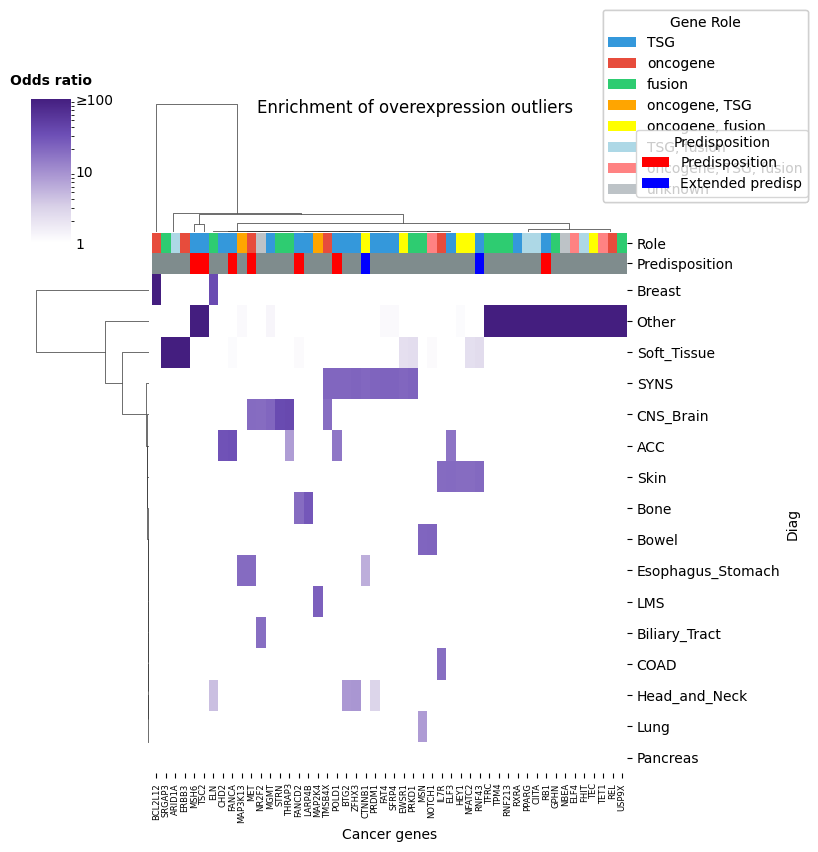

In [315]:
plot_heatmap(odds_ratio_matrix_topk, "Cancer genes", "Enrichment of overexpression outliers")

In [318]:
plot_data = create_fisher_dt(
    or_res,
    "Overexpression",
    cgc_oncogene["gene_name"],
    omics_type="OUTRIDER"
)

plot_data = plot_data[plot_data["TotalAberrantGeneOverall"] > 1]
plot_data.loc[plot_data["A"] == 0, "odds_ratio"] = 0

odds_ratio_matrix = prepare_plot_data(plot_data)

# drop empty columns
odds_ratio_matrix = odds_ratio_matrix.loc[
    :, odds_ratio_matrix.sum(axis=0) != 0
]

# ------------------------------------------------------------
# extract significant entries
# ------------------------------------------------------------

idx = np.where(odds_ratio_matrix.values >= 1)

or_dt = pd.DataFrame({
    "row_name": odds_ratio_matrix.index[idx[0]],
    "col_name": odds_ratio_matrix.columns[idx[1]],
    "odds_pr_overexpression": odds_ratio_matrix.values[idx]
})

or_dt["gene_cancer"] = (
    or_dt["row_name"].astype(str) + "_" +
    or_dt["col_name"].astype(str)
)

or_dt = or_dt.sort_values(
    "odds_pr_overexpression",
    ascending=False
)

genes_of_interest = np.union1d(
    or_dt.iloc[:30]["col_name"].values,
    cgc_tsg["gene_name"].values
)


k = 60
topk_genes = (
    or_dt
    .groupby("col_name")["odds_pr_overexpression"]
    .max()
    .sort_values(ascending=False)
    .head(k)
    .index
)

odds_ratio_matrix_topk = odds_ratio_matrix.loc[
    :, odds_ratio_matrix.columns.intersection(list(topk_genes))
]

# Align roles with the current matrix columns (top50_genes)
# We use .reindex to ensure the order matches the heatmap columns exactly
gene_roles = role_mapping.reindex(odds_ratio_matrix_topk.columns).fillna("unknown")

# Define a color palette for the roles
# You can customize these hex codes as you like
unique_roles = gene_roles.unique()

# Ensure every role in your data has a color (fallback to grey if not in dict)
col_colors = gene_roles.map(lambda x: role_palette.get(x, "#bdc3c7"))


predisp_roles = predisp_role_mapping.reindex(odds_ratio_matrix_topk.columns).fillna("unknown")
unique_predisps = predisp_roles.unique()

# Ensure every role in your data has a color (fallback to grey if not in dict)
col_colors_predisp = predisp_roles.map(lambda x: predisposition_palette.get(x, "#bdc3c7"))

# Assuming dresden_dt_cgc contains both columns
meta_data = cgc[["gene_name", "ROLE_IN_CANCER", "Predisposition"]].copy()
meta_data["ROLE_IN_CANCER"] = meta_data["ROLE_IN_CANCER"].fillna("unknown")
meta_data["Predisposition"] = meta_data["Predisposition"].fillna("unknown")

# Set index to gene_name and reindex to match the matrix columns exactly
meta_mapping = meta_data.set_index("gene_name").reindex(odds_ratio_matrix_topk.columns).fillna("unknown")



# ---------------------------------------------------------
# 3. Create the Color DataFrame
# ---------------------------------------------------------
# Map the values to colors
col_colors = pd.DataFrame(index=meta_mapping.index)
col_colors["Role"] = meta_mapping["ROLE_IN_CANCER"].map(lambda x: role_palette.get(x, "#bdc3c7"))
col_colors["Predisposition"] = meta_mapping["Predisposition"].map(lambda x: predisposition_palette.get(x, "#7f8c8d"))

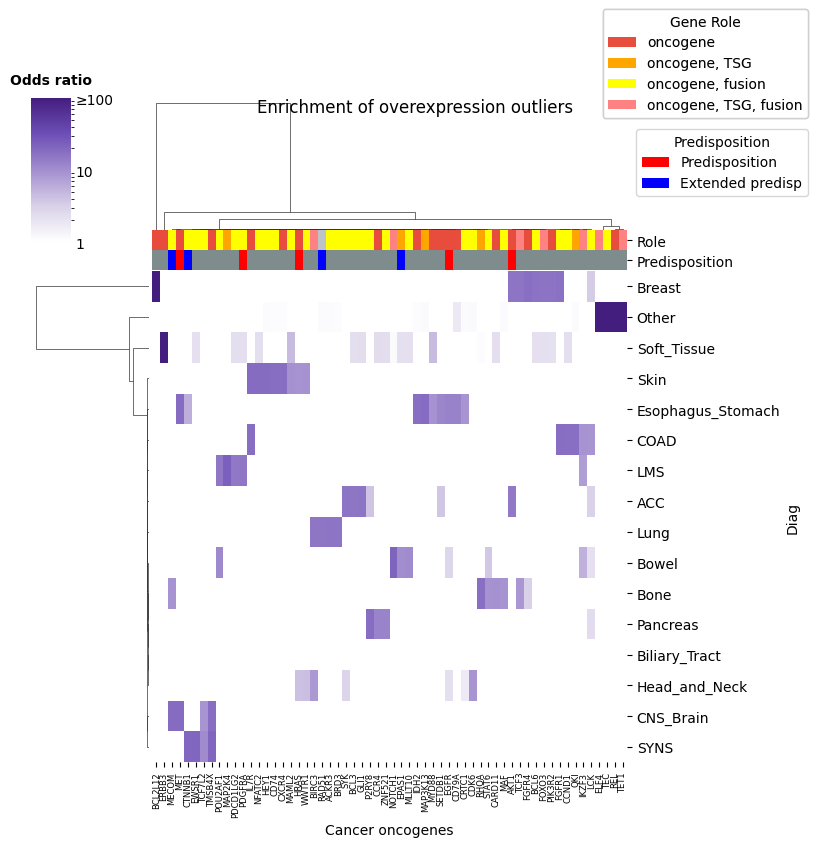

In [319]:
plot_heatmap(odds_ratio_matrix_topk, "Cancer oncogenes", "Enrichment of overexpression outliers")


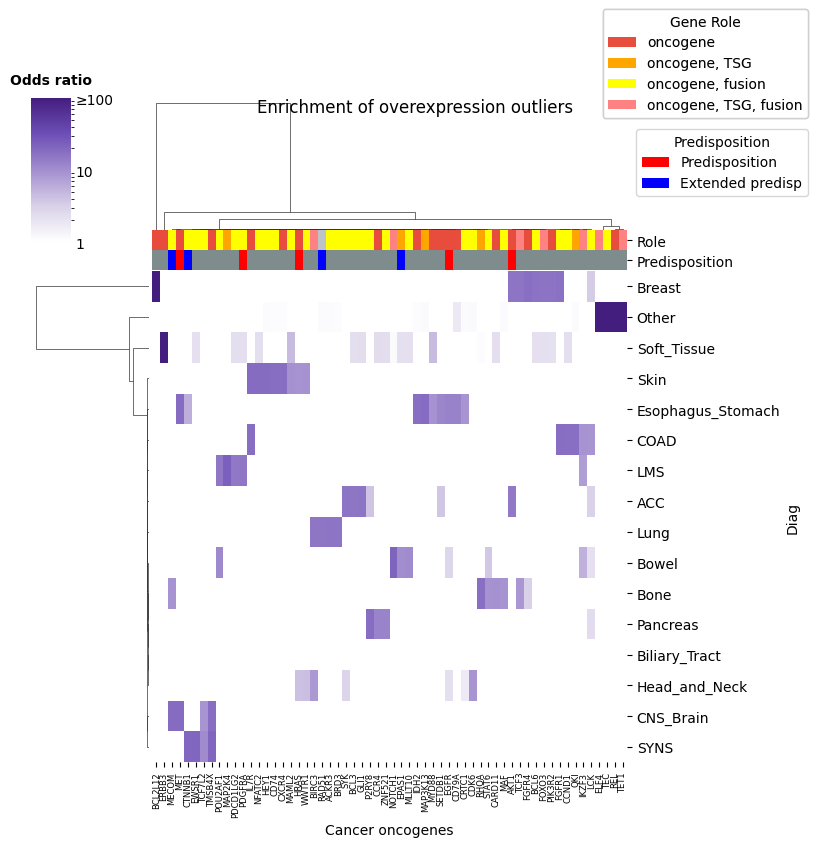

In [324]:

plot_heatmap(odds_ratio_matrix_topk, xlabel="Cancer oncogenes", title="Enrichment of overexpression outliers")

# Proteomics

In [326]:
pr_output_name = "cov_gaussian_gs_lr_0_001_epoc2000_noInitPCA"

pr_res_all = pl.read_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/protrider_runs/output_" + pr_output_name + "/pr_variants_predisppadjust.parquet",
                            columns= ["sampleID", "geneID", "geneID_short", "proteinID", "zScore", "aberrant", "padjust", "padjust_predisp_extended", "padjust_predisp"]
                            )
pr_res_all = pr_res_all.to_pandas()
# pr_res_all = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/protrider_runs/output_" + pr_output_name + "/pr_variants.csv")
pr_res_all = pd.merge(pr_res_all, dresden_dt_cgc[["gene_name", "gene_type", "geneID_short", "ROLE_IN_CANCER", "predisposition_gene"]], right_on="geneID_short", left_on="geneID", how="left")
pr_res_all = pd.merge(pr_res_all, rna_sa[["pid", "Diag", "Oncotree Code"]], left_on="sampleID", right_on="pid")

In [327]:
pr_res_all["aberrant"] = False
pr_res_all.loc[pr_res_all["padjust_predisp_extended"] <= 0.1, "aberrant"] = True
pr_res_all = pr_res_all[pr_res_all["Diag"] != "Unstranded_data"]

## Underexpression

In [332]:
plot_data = create_fisher_dt(
    pr_res_all,
    "Underexpression",
    extended_dresden_dt_cgc["gene_name"],
    omics_type="PROTRIDER",
    cluster_col="Oncotree Code"
)

plot_data = plot_data[plot_data["TotalAberrantGeneOverall"] > 1]
plot_data = plot_data[plot_data["A"] > 1]
plot_data.loc[plot_data["A"] == 0, "odds_ratio"] = 0
plot_data["proportion"] = plot_data["A"]/plot_data["TotalSamplesInDisease"]


odds_ratio_matrix = prepare_plot_data(plot_data)

# drop empty columns
odds_ratio_matrix = odds_ratio_matrix.loc[
    :, odds_ratio_matrix.sum(axis=0) != 0
]

# ------------------------------------------------------------
# extract significant entries
# ------------------------------------------------------------

idx = np.where(odds_ratio_matrix.values >= 1)

or_dt = pd.DataFrame({
    "row_name": odds_ratio_matrix.index[idx[0]],
    "col_name": odds_ratio_matrix.columns[idx[1]],
    "odds_pr_overexpression": odds_ratio_matrix.values[idx]
})

or_dt["gene_cancer"] = (
    or_dt["row_name"].astype(str) + "_" +
    or_dt["col_name"].astype(str)
)

or_dt = or_dt.sort_values(
    "odds_pr_overexpression",
    ascending=False
)


k = 80
topk_genes = (
    or_dt
    .groupby("col_name")["odds_pr_overexpression"]
    .max()
    .sort_values(ascending=False)
    .head(k)
    .index
)

odds_ratio_matrix = odds_ratio_matrix.loc[list(set(suff_cohorts).intersection(set(odds_ratio_matrix.index)))]
odds_ratio_matrix = odds_ratio_matrix.loc[odds_ratio_matrix.sum(axis=1) > 1]

odds_ratio_matrix_topk = odds_ratio_matrix.loc[
    :, odds_ratio_matrix.columns.intersection(list(topk_genes))
]

# Set index to gene_name and reindex to match the matrix columns exactly
meta_mapping = meta_data.set_index("gene_name").reindex(odds_ratio_matrix_topk.columns).fillna("unknown")



# ---------------------------------------------------------
# 3. Create the Color DataFrame
# ---------------------------------------------------------
# Map the values to colors
col_colors = pd.DataFrame(index=meta_mapping.index)
col_colors["Role"] = meta_mapping["ROLE_IN_CANCER"].map(lambda x: role_palette.get(x, "#bdc3c7"))
col_colors["Predisposition"] = meta_mapping["Predisposition"].map(lambda x: predisposition_palette.get(x, "#7f8c8d"))

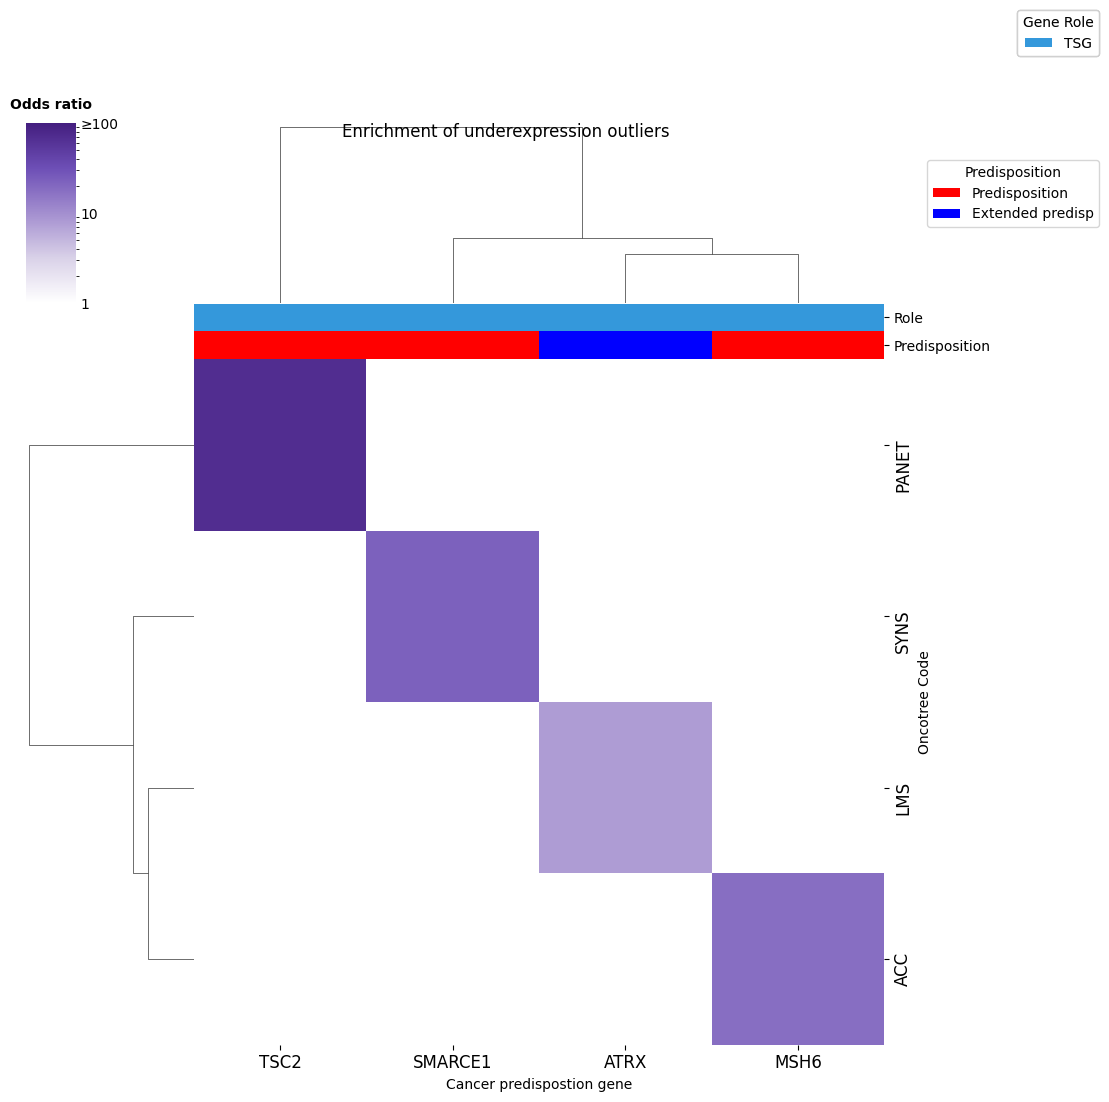

In [333]:
plot_heatmap(odds_ratio_matrix_topk, "Cancer predispostion gene", "Enrichment of underexpression outliers", ylabel="Oncotree Code", yfont_size=12, xfont_size=12)

In [354]:
or_dt.iloc[:8]["col_name"]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


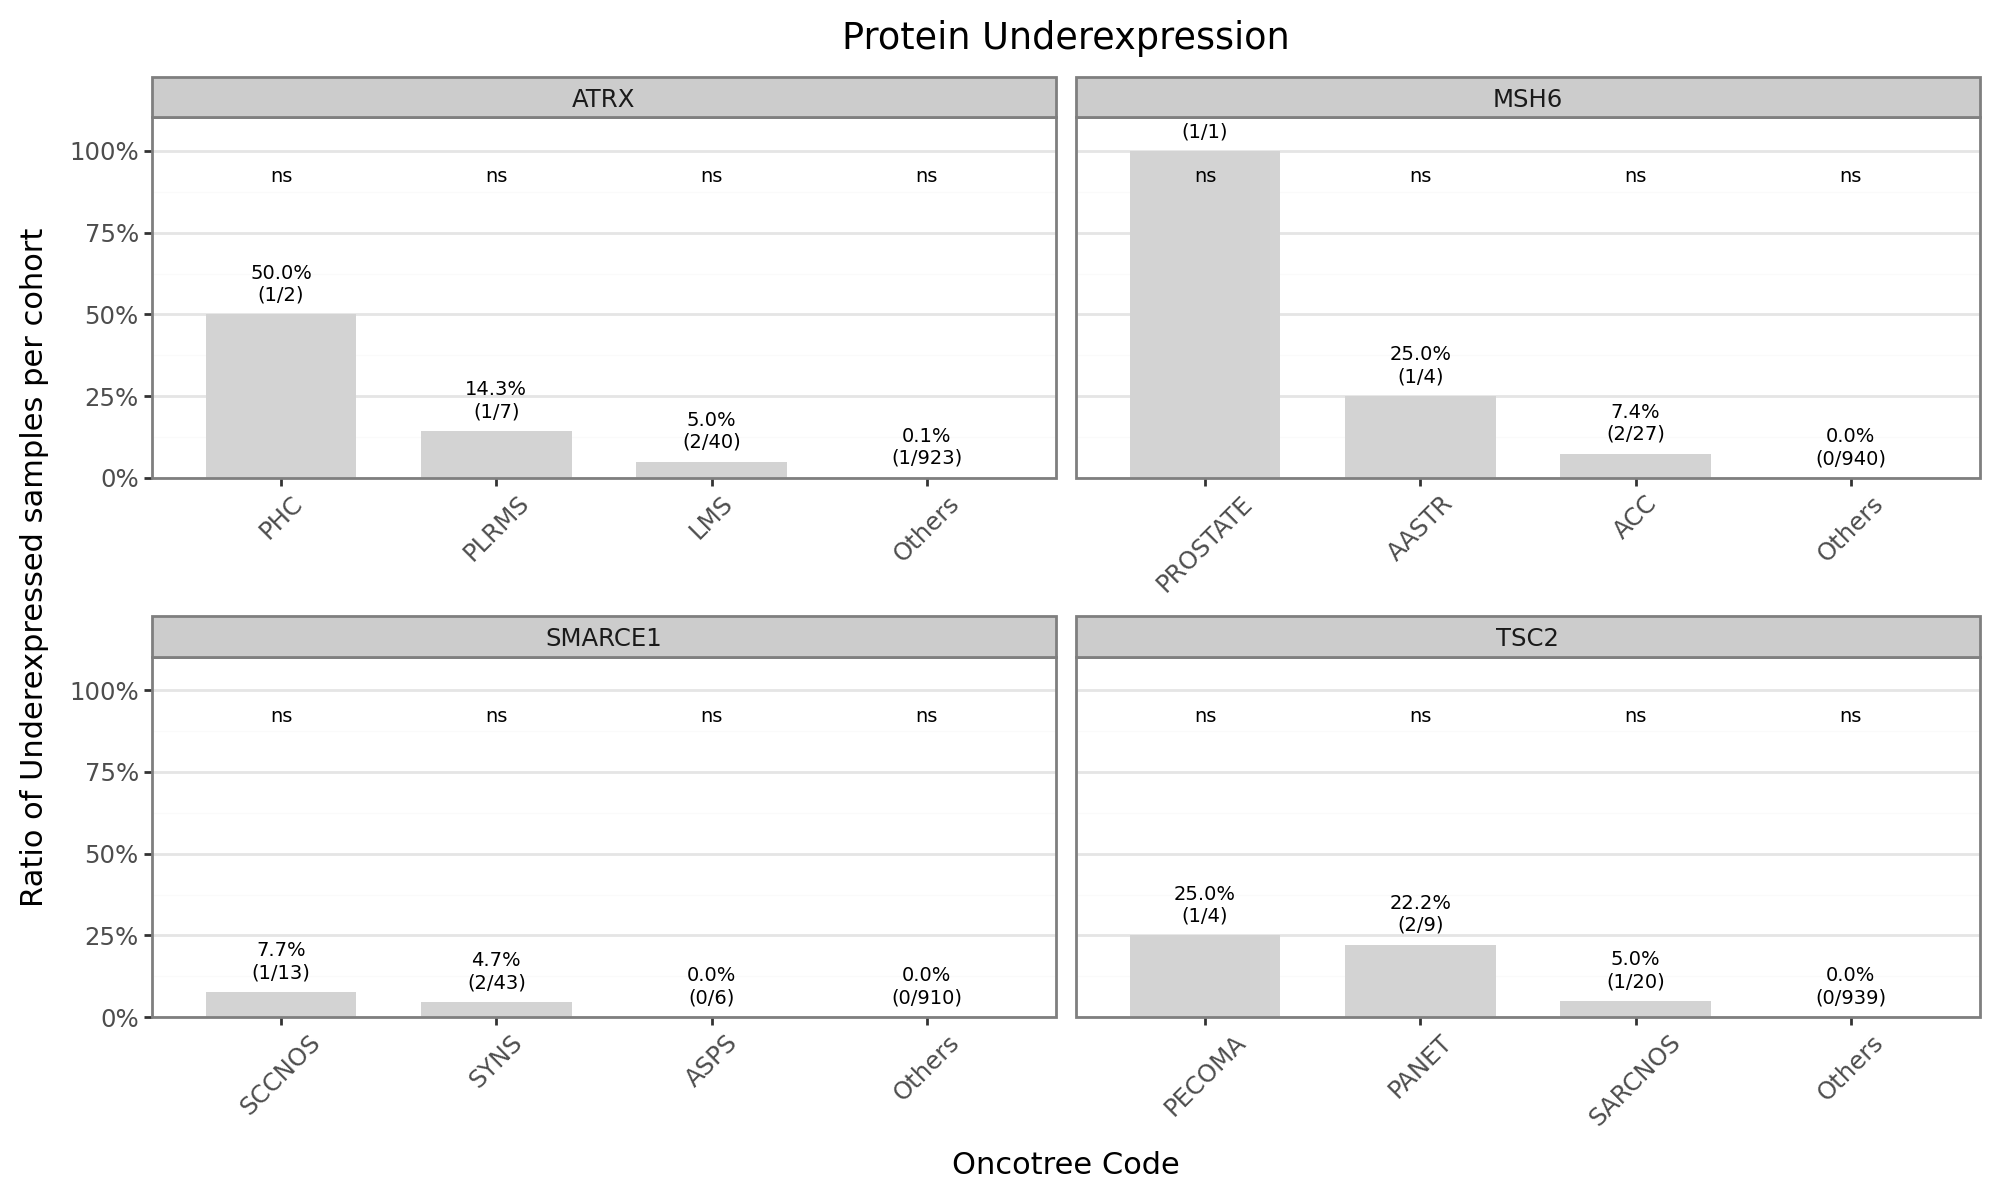

In [355]:

plot_dt = create_proportions_per_entity(pr_res_all, ["SMARCE1", "ATRX", "MSH6", "TSC2"], "Underexpression", id_col="proteinID", keep_sig=False)
# Ensure the order is preserved (Top 1, 2, 3, then Others)
plot = (
    ggplot(plot_dt, aes(x='reorder(disease, -ratio)', y='ratio'))
    + facet_wrap("gene_name", scales="free_x", nrow=2)
    + geom_col(fill="#d3d3d3", width=0.7)
    + geom_text(aes(label='top_label'), va='bottom', nudge_y=0.03, size=7)
    + geom_text(aes(label='stars'), y=0.92, size=7)
    + scale_y_continuous(labels=lambda l: [f"{int(x*100)}%" for x in l],
                         limits=[0, 1.05],
                         expand=(0, 0, 0.05, 0)
                        )
    + labs(x="Oncotree Code", y=f"Ratio of Underexpressed samples per cohort", title=f"Protein Underexpression")
    + theme_bw()
    + theme(panel_grid_major_x=element_blank(), axis_text_x=element_text(rotation=45), figure_size=(10, 6))
)

plot

## Overexpression

In [346]:
plot_data = create_fisher_dt(
    pr_res_all,
    "Overexpression",
    extended_dresden_dt_cgc["gene_name"],
    omics_type="PROTRIDER",
    cluster_col="Oncotree Code"
)

plot_data = plot_data[plot_data["TotalAberrantGeneOverall"] > 1]
plot_data = plot_data[plot_data["A"] > 1]
plot_data.loc[plot_data["A"] == 0, "odds_ratio"] = 0

plot_data["proportion"] = plot_data["A"]/plot_data["TotalSamplesInDisease"]


odds_ratio_matrix = prepare_plot_data(plot_data)

# drop empty columns
odds_ratio_matrix = odds_ratio_matrix.loc[
    :, odds_ratio_matrix.sum(axis=0) != 0
]

# ------------------------------------------------------------
# extract significant entries
# ------------------------------------------------------------

idx = np.where(odds_ratio_matrix.values >= 1)

or_dt = pd.DataFrame({
    "row_name": odds_ratio_matrix.index[idx[0]],
    "col_name": odds_ratio_matrix.columns[idx[1]],
    "odds_pr_overexpression": odds_ratio_matrix.values[idx]
})

or_dt["gene_cancer"] = (
    or_dt["row_name"].astype(str) + "_" +
    or_dt["col_name"].astype(str)
)

or_dt = or_dt.sort_values(
    "odds_pr_overexpression",
    ascending=False
)

genes_of_interest = np.union1d(
    or_dt.iloc[:30]["col_name"].values,
    cgc_tsg["gene_name"].values
)


k = 100
topk_genes = (
    or_dt
    .groupby("col_name")["odds_pr_overexpression"]
    .max()
    .sort_values(ascending=False)
    .head(k)
    .index
)

odds_ratio_matrix_topk = odds_ratio_matrix.loc[
    :, odds_ratio_matrix.columns.intersection(list(topk_genes))
]

# Align roles with the current matrix columns (top50_genes)
# We use .reindex to ensure the order matches the heatmap columns exactly
gene_roles = role_mapping.reindex(odds_ratio_matrix_topk.columns).fillna("unknown")

# Define a color palette for the roles
# You can customize these hex codes as you like
unique_roles = gene_roles.unique()

# Ensure every role in your data has a color (fallback to grey if not in dict)
col_colors = gene_roles.map(lambda x: role_palette.get(x, "#bdc3c7"))


predisp_roles = predisp_role_mapping.reindex(odds_ratio_matrix_topk.columns).fillna("unknown")
unique_predisps = predisp_roles.unique()

# Ensure every role in your data has a color (fallback to grey if not in dict)
col_colors_predisp = predisp_roles.map(lambda x: predisposition_palette.get(x, "#bdc3c7"))

# Set index to gene_name and reindex to match the matrix columns exactly
meta_mapping = meta_data.set_index("gene_name").reindex(odds_ratio_matrix_topk.columns).fillna("unknown")



# ---------------------------------------------------------
# 3. Create the Color DataFrame
# ---------------------------------------------------------
# Map the values to colors
col_colors = pd.DataFrame(index=meta_mapping.index)
col_colors["Role"] = meta_mapping["ROLE_IN_CANCER"].map(lambda x: role_palette.get(x, "#bdc3c7"))
col_colors["Predisposition"] = meta_mapping["Predisposition"].map(lambda x: predisposition_palette.get(x, "#7f8c8d"))

In [371]:
pr_res_all[(pr_res_all["padjust"] <= 0.1) & (pr_res_all["zScore"] > 0)][["proteinID", "Oncotree Code"]].value_counts()

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


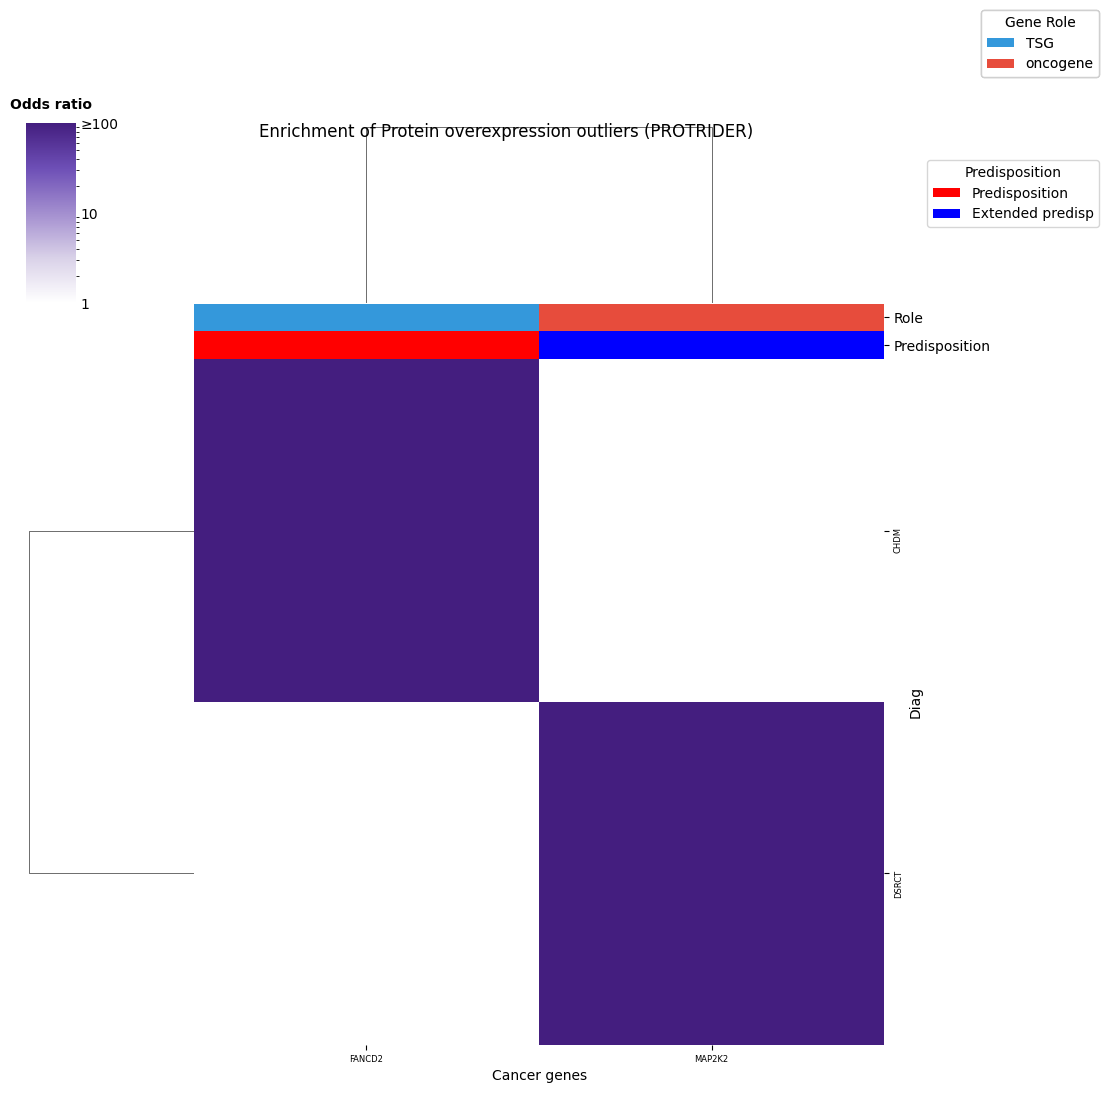

In [337]:

plot_heatmap(odds_ratio_matrix_topk, xlabel="Cancer genes", title="Enrichment of Protein overexpression outliers (PROTRIDER)")

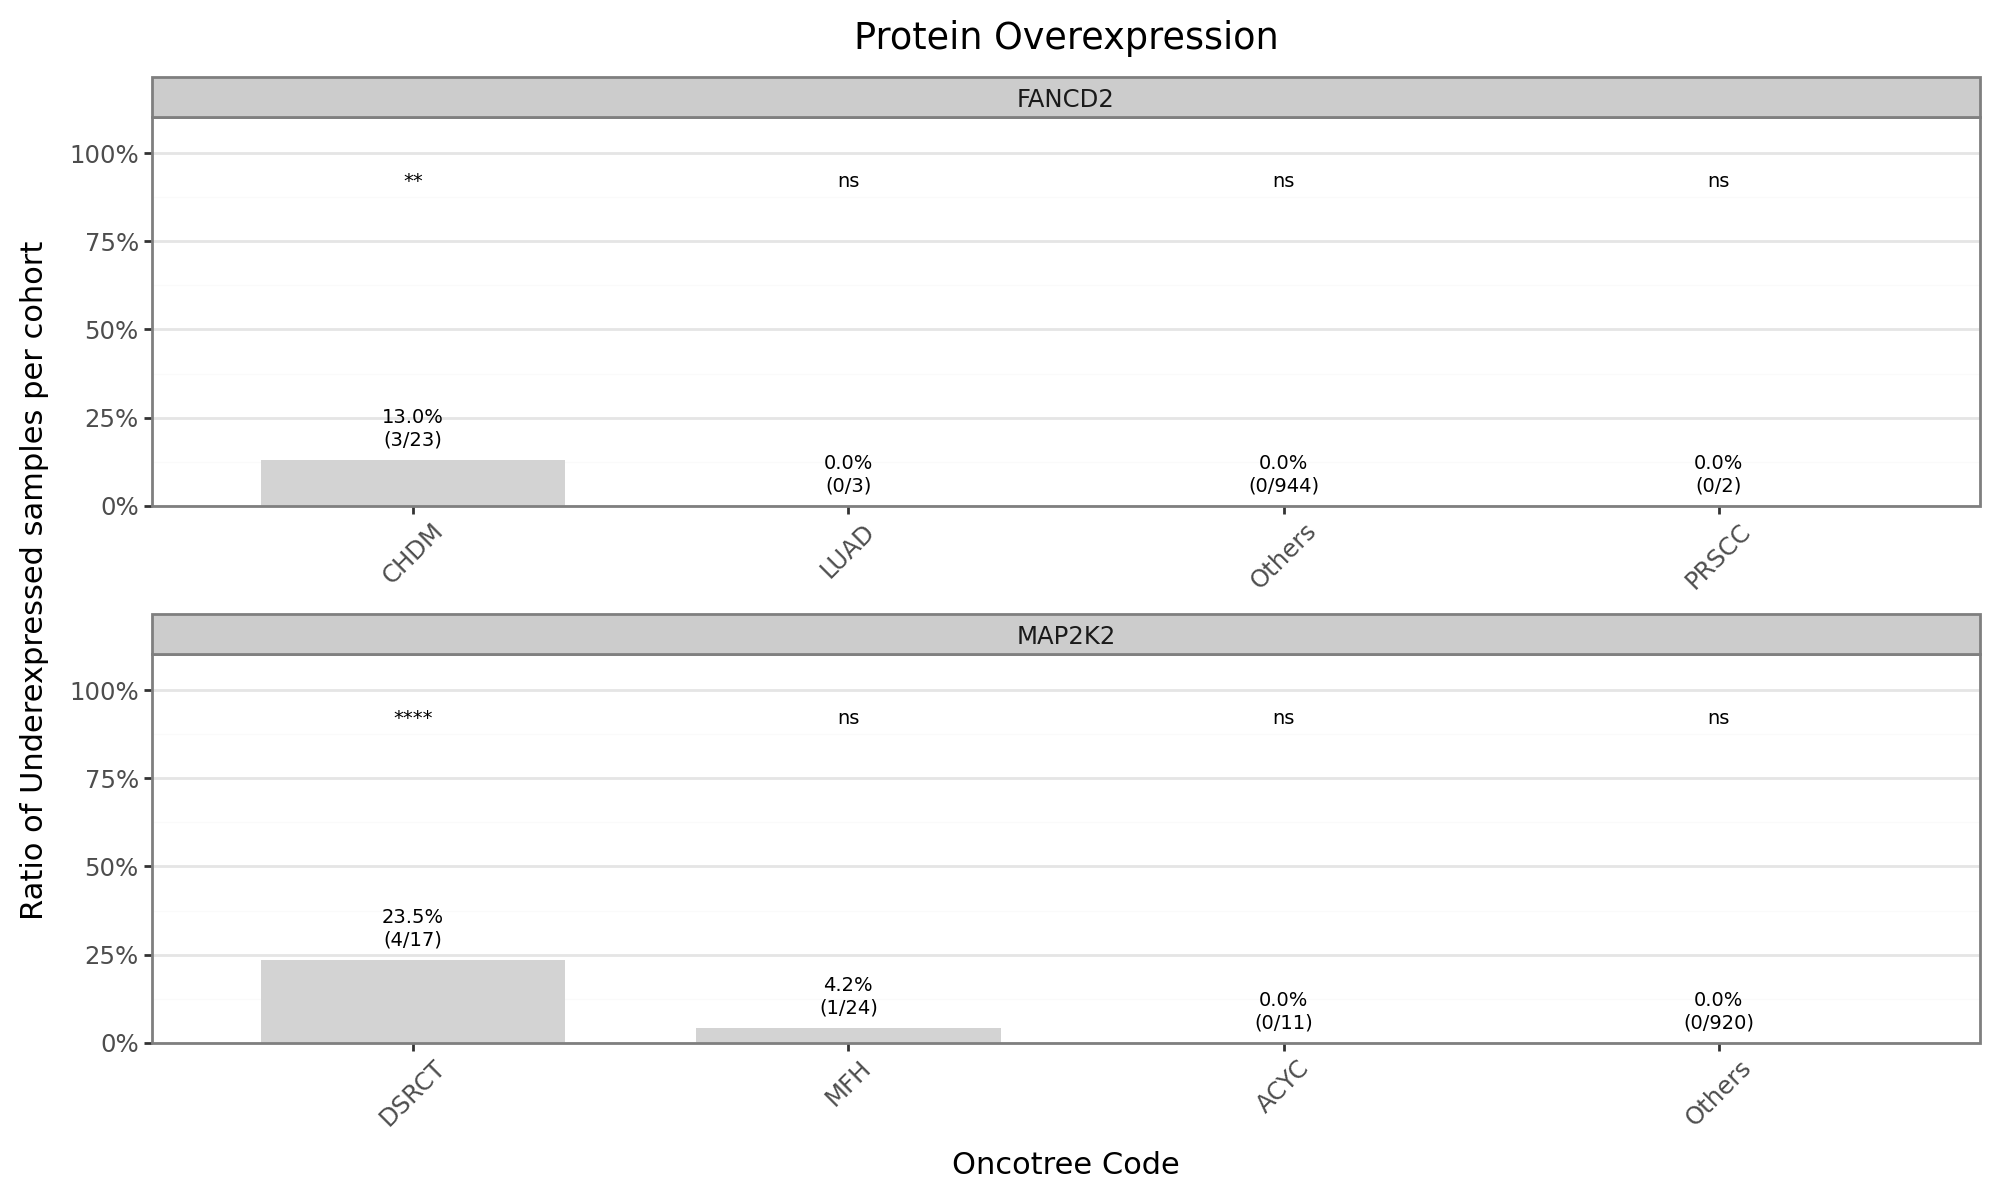

In [356]:

plot_dt = create_proportions_per_entity(pr_res_all, ["FANCD2", "MAP2K2" ], "Overexpression", id_col="proteinID", keep_sig=False)
# Ensure the order is preserved (Top 1, 2, 3, then Others)
plot = (
    ggplot(plot_dt, aes(x='reorder(disease, -ratio)', y='ratio'))
    + facet_wrap("gene_name", scales="free_x", nrow=2)
    + geom_col(fill="#d3d3d3", width=0.7)
    + geom_text(aes(label='top_label'), va='bottom', nudge_y=0.03, size=7)
    + geom_text(aes(label='stars'), y=0.92, size=7)
    + scale_y_continuous(labels=lambda l: [f"{int(x*100)}%" for x in l],
                         limits=[0, 1.05],
                         expand=(0, 0, 0.05, 0)
                        )
    + labs(x="Oncotree Code", y=f"Ratio of Underexpressed samples per cohort", title=f"Protein Overexpression")
    + theme_bw()
    + theme(panel_grid_major_x=element_blank(), axis_text_x=element_text(rotation=45), figure_size=(10, 6))
)

plot

# Splicing outliers

In [372]:
needed_cols = ["sampleID", "hgncSymbol", "padjust", "deltaPsi", "Diag", "start", "end"]
fr_res = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/drop_runs/drop_master_202502_allGenes/processed_results/aberrant_splicing/results/v19/fraser/aggregated_results_gene_all.tsv", sep="\t", usecols=needed_cols,)

In [379]:
fr_res["aberrant"] = False
fr_res.loc[(fr_res["padjust"] <= 0.1) & (abs(fr_res["deltaPsi"]) >= 0.1), "aberrant"] = True
fr_res = fr_res.merge(rna_sa[["pid", "Oncotree Code"]], left_on="sampleID", right_on="pid")

In [382]:
extended_dresden_dt_cgc

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [397]:
plot_data = create_fisher_dt(
    fr_res,
    "splicing",
    extended_dresden_dt_cgc["gene_name"],
    omics_type="FRASER",
    cluster_col="Oncotree Code"
)

plot_data = plot_data[plot_data["TotalAberrantGeneOverall"] > 1]
plot_data = plot_data[plot_data["A"] > 1]

plot_data.loc[plot_data["A"] == 0, "odds_ratio"] = 0

odds_ratio_matrix = prepare_plot_data(plot_data)

# drop empty columns
odds_ratio_matrix = odds_ratio_matrix.loc[
    :, odds_ratio_matrix.sum(axis=0) != 0
]

# ------------------------------------------------------------
# extract significant entries
# ------------------------------------------------------------

odds_ratio_matrix = odds_ratio_matrix.loc[list(set(suff_cohorts).intersection(set(odds_ratio_matrix.index)))]

idx = np.where(odds_ratio_matrix.values >= 1)

or_dt = pd.DataFrame({
    "row_name": odds_ratio_matrix.index[idx[0]],
    "col_name": odds_ratio_matrix.columns[idx[1]],
    "odds_pr_overexpression": odds_ratio_matrix.values[idx]
})

or_dt["gene_cancer"] = (
    or_dt["row_name"].astype(str) + "_" +
    or_dt["col_name"].astype(str)
)

or_dt = or_dt.sort_values(
    "odds_pr_overexpression",
    ascending=False
)


k = 65
topk_genes = (
    or_dt
    .groupby("col_name")["odds_pr_overexpression"]
    .max()
    .sort_values(ascending=False)
    .head(k)
    .index
)


odds_ratio_matrix_topk = odds_ratio_matrix.loc[
    :, odds_ratio_matrix.columns.intersection(list(topk_genes))
]
odds_ratio_matrix_topk = odds_ratio_matrix_topk.loc[odds_ratio_matrix_topk.sum(axis=1) > 2]



# Set index to gene_name and reindex to match the matrix columns exactly
meta_mapping = meta_data.set_index("gene_name").reindex(odds_ratio_matrix_topk.columns).fillna("unknown")



# ---------------------------------------------------------
# 3. Create the Color DataFrame
# ---------------------------------------------------------
# Map the values to colors
col_colors = pd.DataFrame(index=meta_mapping.index)
col_colors["Role"] = meta_mapping["ROLE_IN_CANCER"].map(lambda x: role_palette.get(x, "#bdc3c7"))
col_colors["Predisposition"] = meta_mapping["Predisposition"].map(lambda x: predisposition_palette.get(x, "#7f8c8d"))

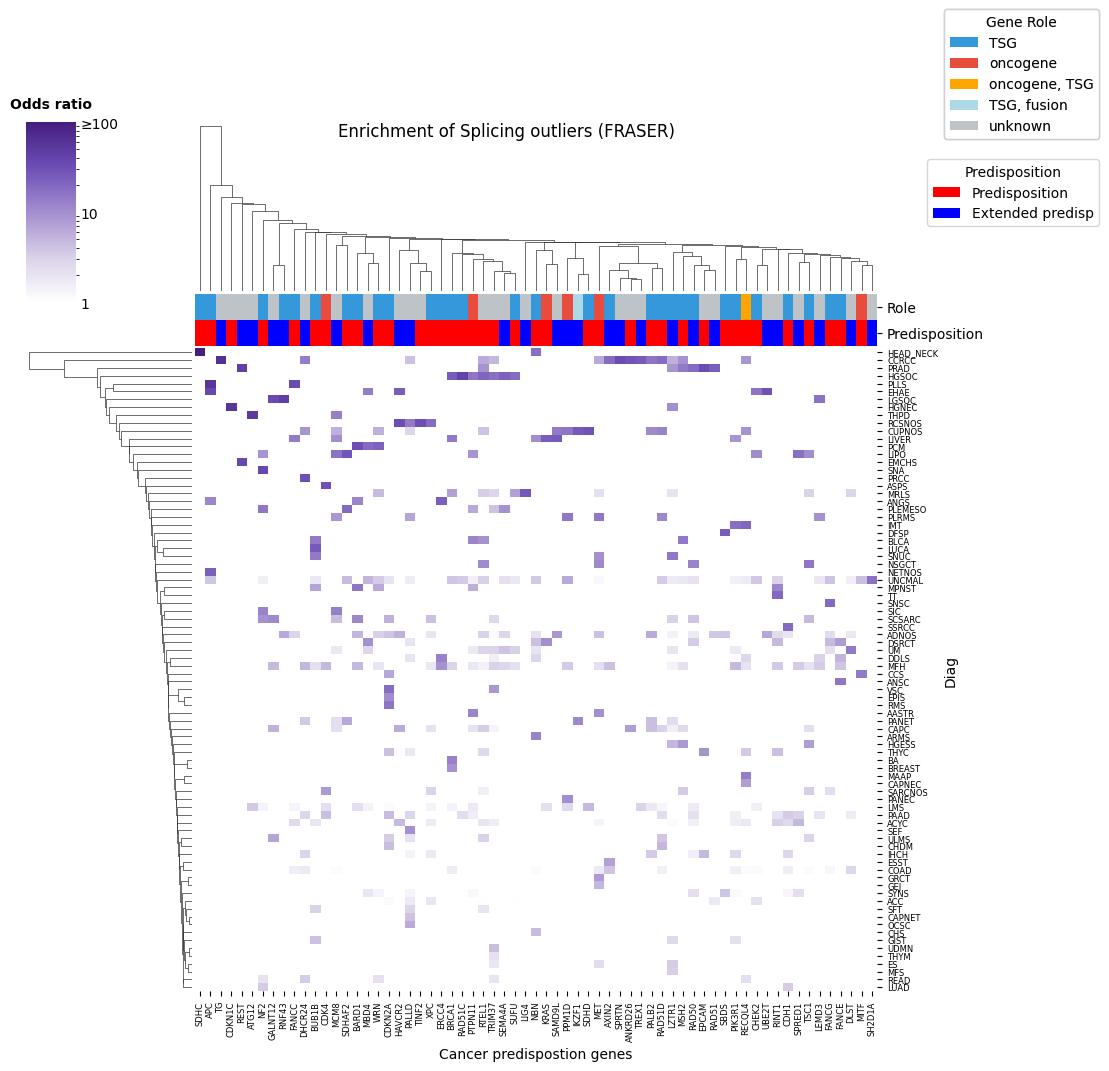

In [398]:

plot_heatmap(odds_ratio_matrix_topk, xlabel="Cancer predispostion genes", title="Enrichment of Splicing outliers (FRASER)")

In [400]:
fr_res.head()

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


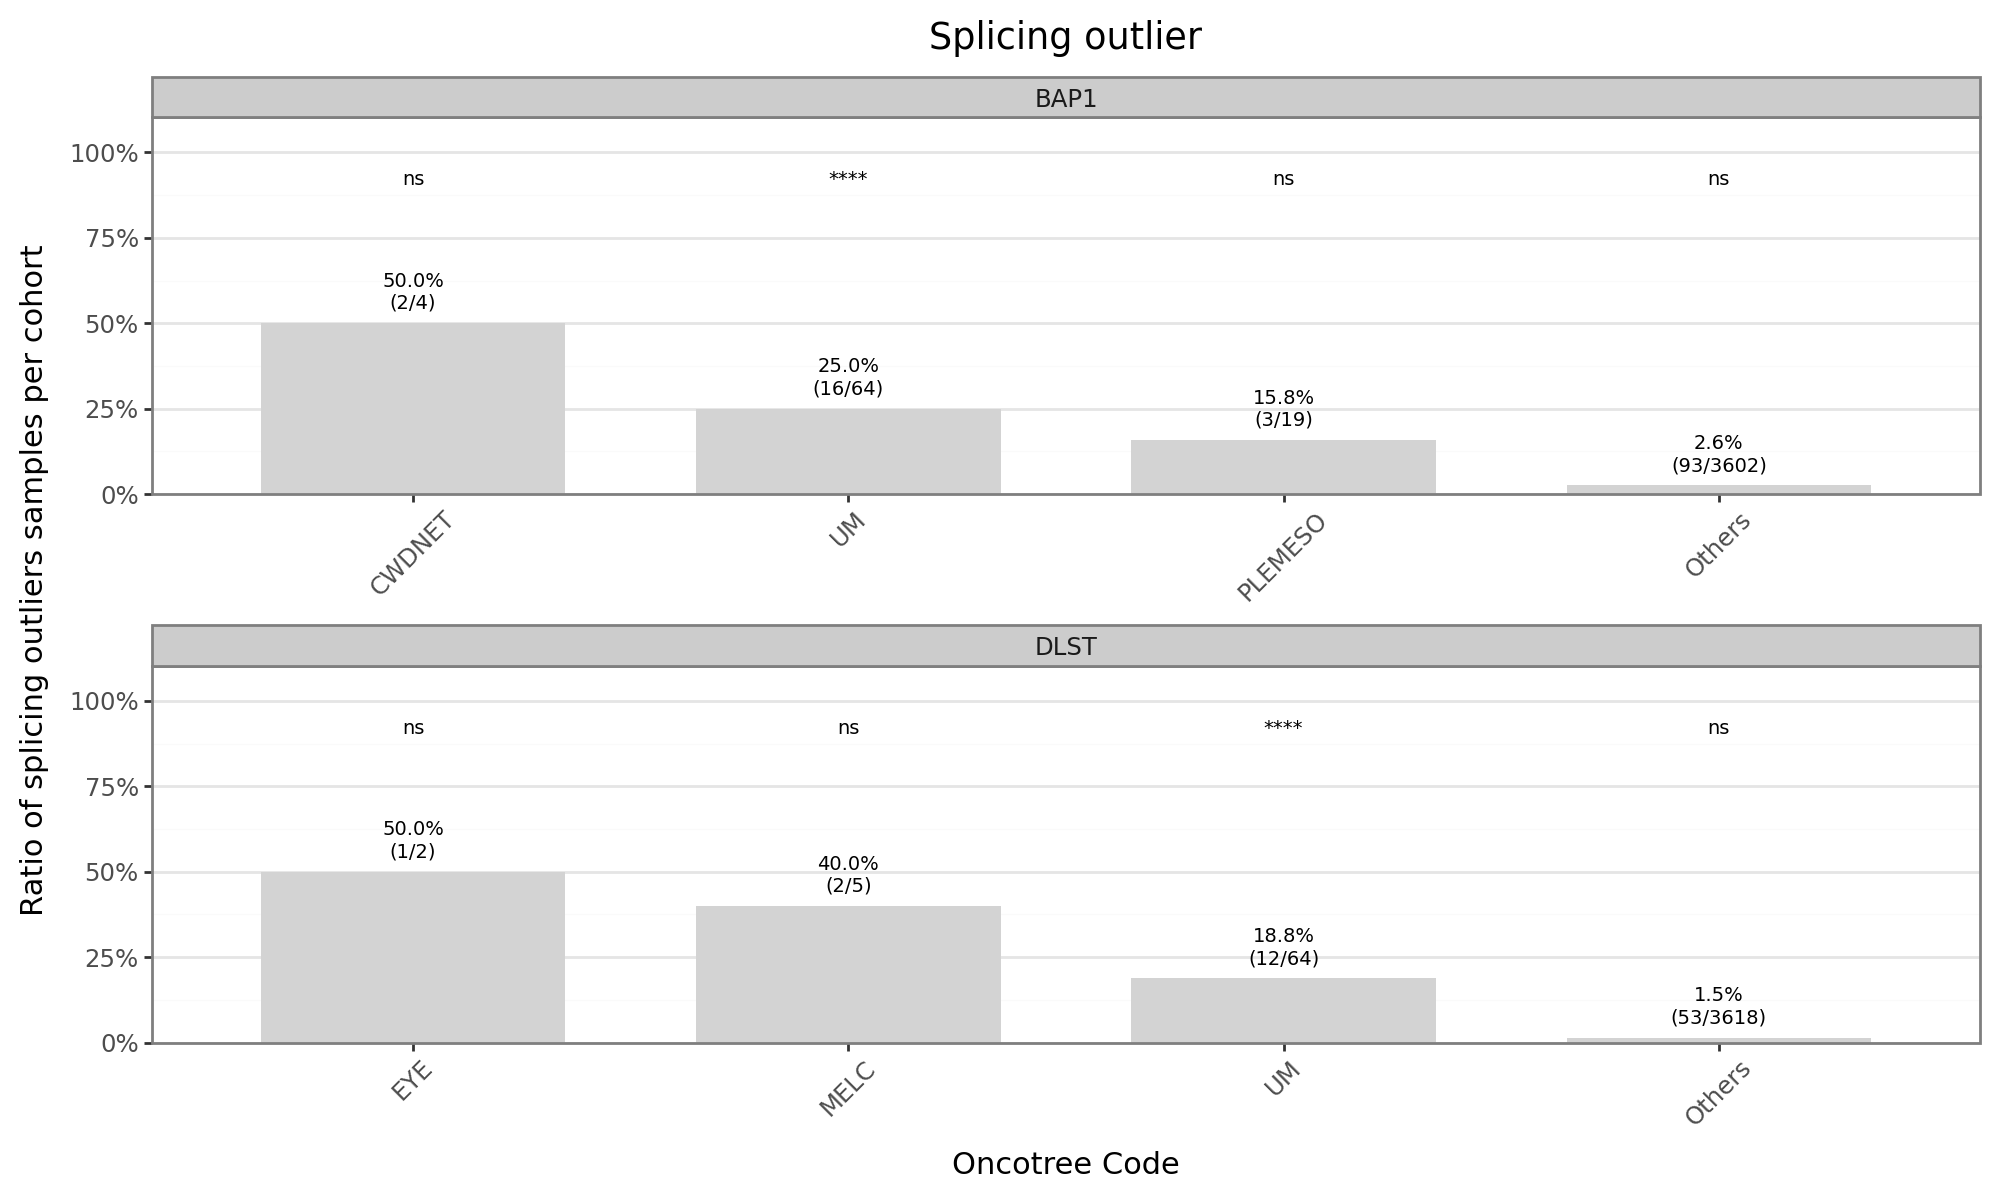

In [429]:
plot_dt = create_proportions_per_entity(fr_res, ["BAP1", "DLST"],
                                        "Splicing", id_col="hgncSymbol", keep_sig=True)
# Ensure the order is preserved (Top 1, 2, 3, then Others)
plot = (
    ggplot(plot_dt, aes(x='reorder(disease, -ratio)', y='ratio'))
    + facet_wrap("gene_name", scales="free_x", nrow=2)
    + geom_col(fill="#d3d3d3", width=0.7)
    + geom_text(aes(label='top_label'), va='bottom', nudge_y=0.03, size=7)
    + geom_text(aes(label='stars'), y=0.92, size=7)
    + scale_y_continuous(labels=lambda l: [f"{int(x*100)}%" for x in l],
                         limits=[0, 1.05],
                         expand=(0, 0, 0.05, 0)
                        )
    + labs(x="Oncotree Code", y=f"Ratio of splicing outliers samples per cohort", title=f"Splicing outlier")
    + theme_bw()
    + theme(panel_grid_major_x=element_blank(), axis_text_x=element_text(rotation=45), figure_size=(10, 6))
)

plot

In [413]:
fr_res.head()

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [427]:
fr_res[(fr_res["padjust"] <= 0.1) & (fr_res["hgncSymbol"].isin(extended_dresden_dt_cgc["gene_name"]))][["Oncotree Code", "hgncSymbol"]].value_counts()[30:40]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


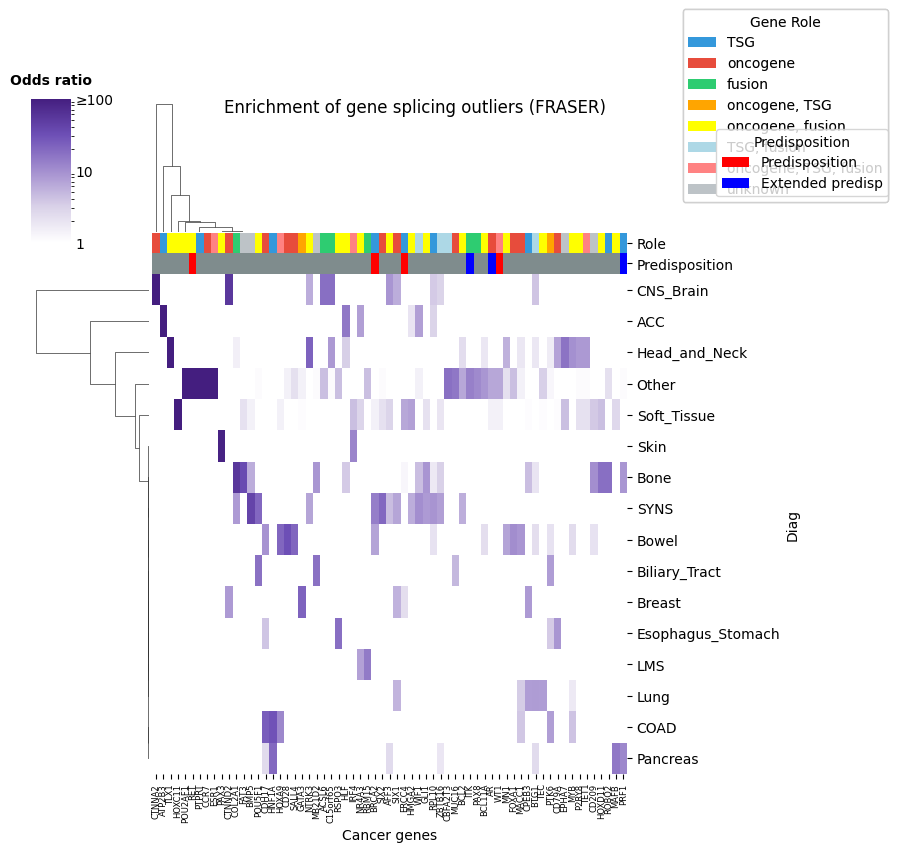

In [36]:

plot_heatmap(odds_ratio_matrix_topk, xlabel="Cancer genes", title="Enrichment of gene splicing outliers (FRASER)")

In [49]:
plot_data = create_fisher_dt(
    fr_res,
    "Overexpression",
    extended_dresden_dt["gene_name"],
    omics_type="FRASER"
)

plot_data = plot_data[plot_data["TotalAberrantGeneOverall"] > 1]
plot_data.loc[plot_data["A"] == 0, "odds_ratio"] = 0

odds_ratio_matrix = prepare_plot_data(plot_data)

# drop empty columns
odds_ratio_matrix = odds_ratio_matrix.loc[
    :, odds_ratio_matrix.sum(axis=0) != 0
]

# ------------------------------------------------------------
# extract significant entries
# ------------------------------------------------------------

idx = np.where(odds_ratio_matrix.values >= 1)

or_dt = pd.DataFrame({
    "row_name": odds_ratio_matrix.index[idx[0]],
    "col_name": odds_ratio_matrix.columns[idx[1]],
    "odds_pr_overexpression": odds_ratio_matrix.values[idx]
})

or_dt["gene_cancer"] = (
    or_dt["row_name"].astype(str) + "_" +
    or_dt["col_name"].astype(str)
)

or_dt = or_dt.sort_values(
    "odds_pr_overexpression",
    ascending=False
)

genes_of_interest = np.union1d(
    or_dt.iloc[:30]["col_name"].values,
    cgc_tsg["gene_name"].values
)


k = 30
topk_genes = (
    or_dt
    .groupby("col_name")["odds_pr_overexpression"]
    .max()
    .sort_values(ascending=False)
    .head(k)
    .index
)

odds_ratio_matrix_topk = odds_ratio_matrix.loc[
    :, odds_ratio_matrix.columns.intersection(list(topk_genes))
]

# Align roles with the current matrix columns (top50_genes)
# We use .reindex to ensure the order matches the heatmap columns exactly
gene_roles = role_mapping.reindex(odds_ratio_matrix_topk.columns).fillna("unknown")

# Define a color palette for the roles
# You can customize these hex codes as you like
unique_roles = gene_roles.unique()

# Ensure every role in your data has a color (fallback to grey if not in dict)
col_colors = gene_roles.map(lambda x: role_palette.get(x, "#bdc3c7"))


predisp_roles = predisp_role_mapping.reindex(odds_ratio_matrix_topk.columns).fillna("unknown")
unique_predisps = predisp_roles.unique()

# Ensure every role in your data has a color (fallback to grey if not in dict)
col_colors_predisp = predisp_roles.map(lambda x: predisposition_palette.get(x, "#bdc3c7"))


# Assuming dresden_dt_cgc contains both columns
meta_data = extended_dresden_dt_cgc[["gene_name", "ROLE_IN_CANCER", "Predisposition"]].copy()
meta_data["ROLE_IN_CANCER"] = meta_data["ROLE_IN_CANCER"].fillna("unknown")
meta_data["Predisposition"] = meta_data["Predisposition"].fillna("unknown")

# Set index to gene_name and reindex to match the matrix columns exactly
meta_mapping = meta_data.set_index("gene_name").reindex(odds_ratio_matrix_topk.columns).fillna("unknown")



# ---------------------------------------------------------
# 3. Create the Color DataFrame
# ---------------------------------------------------------
# Map the values to colors
col_colors = pd.DataFrame(index=meta_mapping.index)
col_colors["Role"] = meta_mapping["ROLE_IN_CANCER"].map(lambda x: role_palette.get(x, "#bdc3c7"))
col_colors["Predisposition"] = meta_mapping["Predisposition"].map(lambda x: predisposition_palette.get(x, "#7f8c8d"))

In [ ]:
meta_mapping

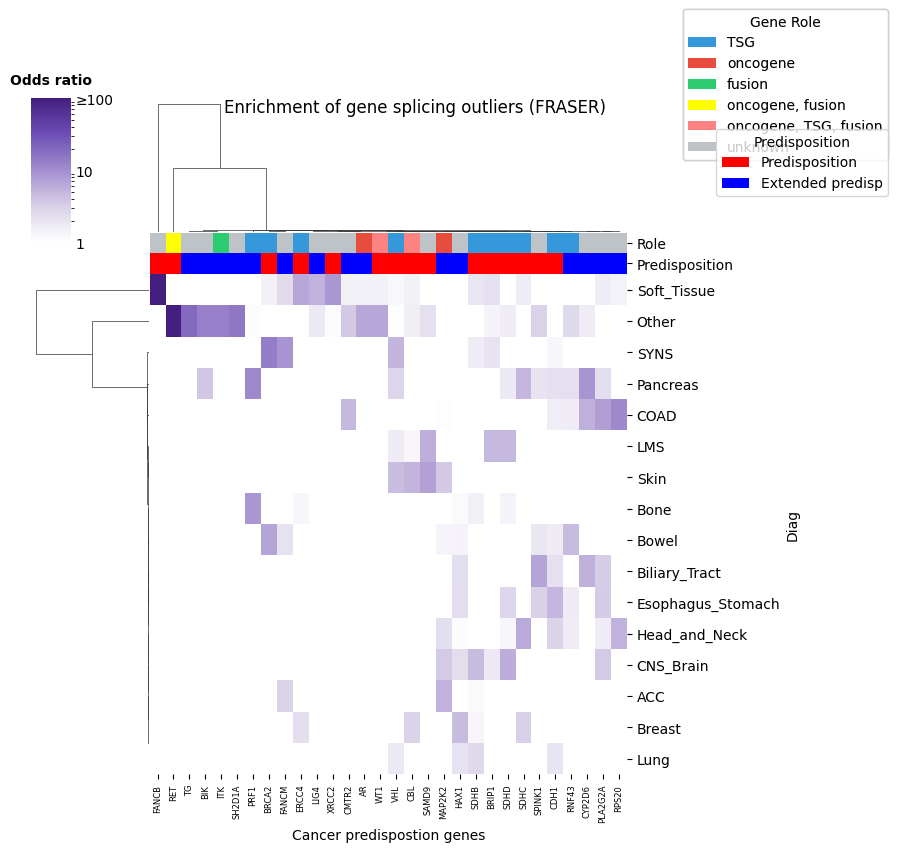

In [50]:

plot_heatmap(odds_ratio_matrix_topk, xlabel="Cancer predispostion genes", title="Enrichment of gene splicing outliers (FRASER)")

# Activation

In [437]:
mu = 5
theta = 100
activation_res = pd.read_csv(f"/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/drop_runs/drop_master_202502_allGenes/processed_results/aberrant_expression/v19/nb_act/activation_res_protein_coding_genes_sig_theta{theta}_mu{mu}_BH.tsv", sep="\t")

activation_res = activation_res.merge(rna_sa[["pid", "Diag", "Oncotree Code", "SEX", "ICD10 Code", "TISSUE", "Tumorzellgehalt (Bioinformatik)"]], how="left", left_on="sampleID", right_on= "pid")

activation_res = activation_res.merge(gene_annot_dt, left_on="geneID", right_on = "gene_id")
activation_res = activation_res.rename(columns={"geneID": "geneID_long"})
activation_res = activation_res.rename(columns={"gene_name": "geneID"})

activation_res["aberrant"] = True



In [441]:
activation_res

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [443]:
activation_res[activation_res["geneID"].isin(extended_dresden_dt_cgc["gene_name"])][["Oncotree Code", "geneID"]].value_counts()

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


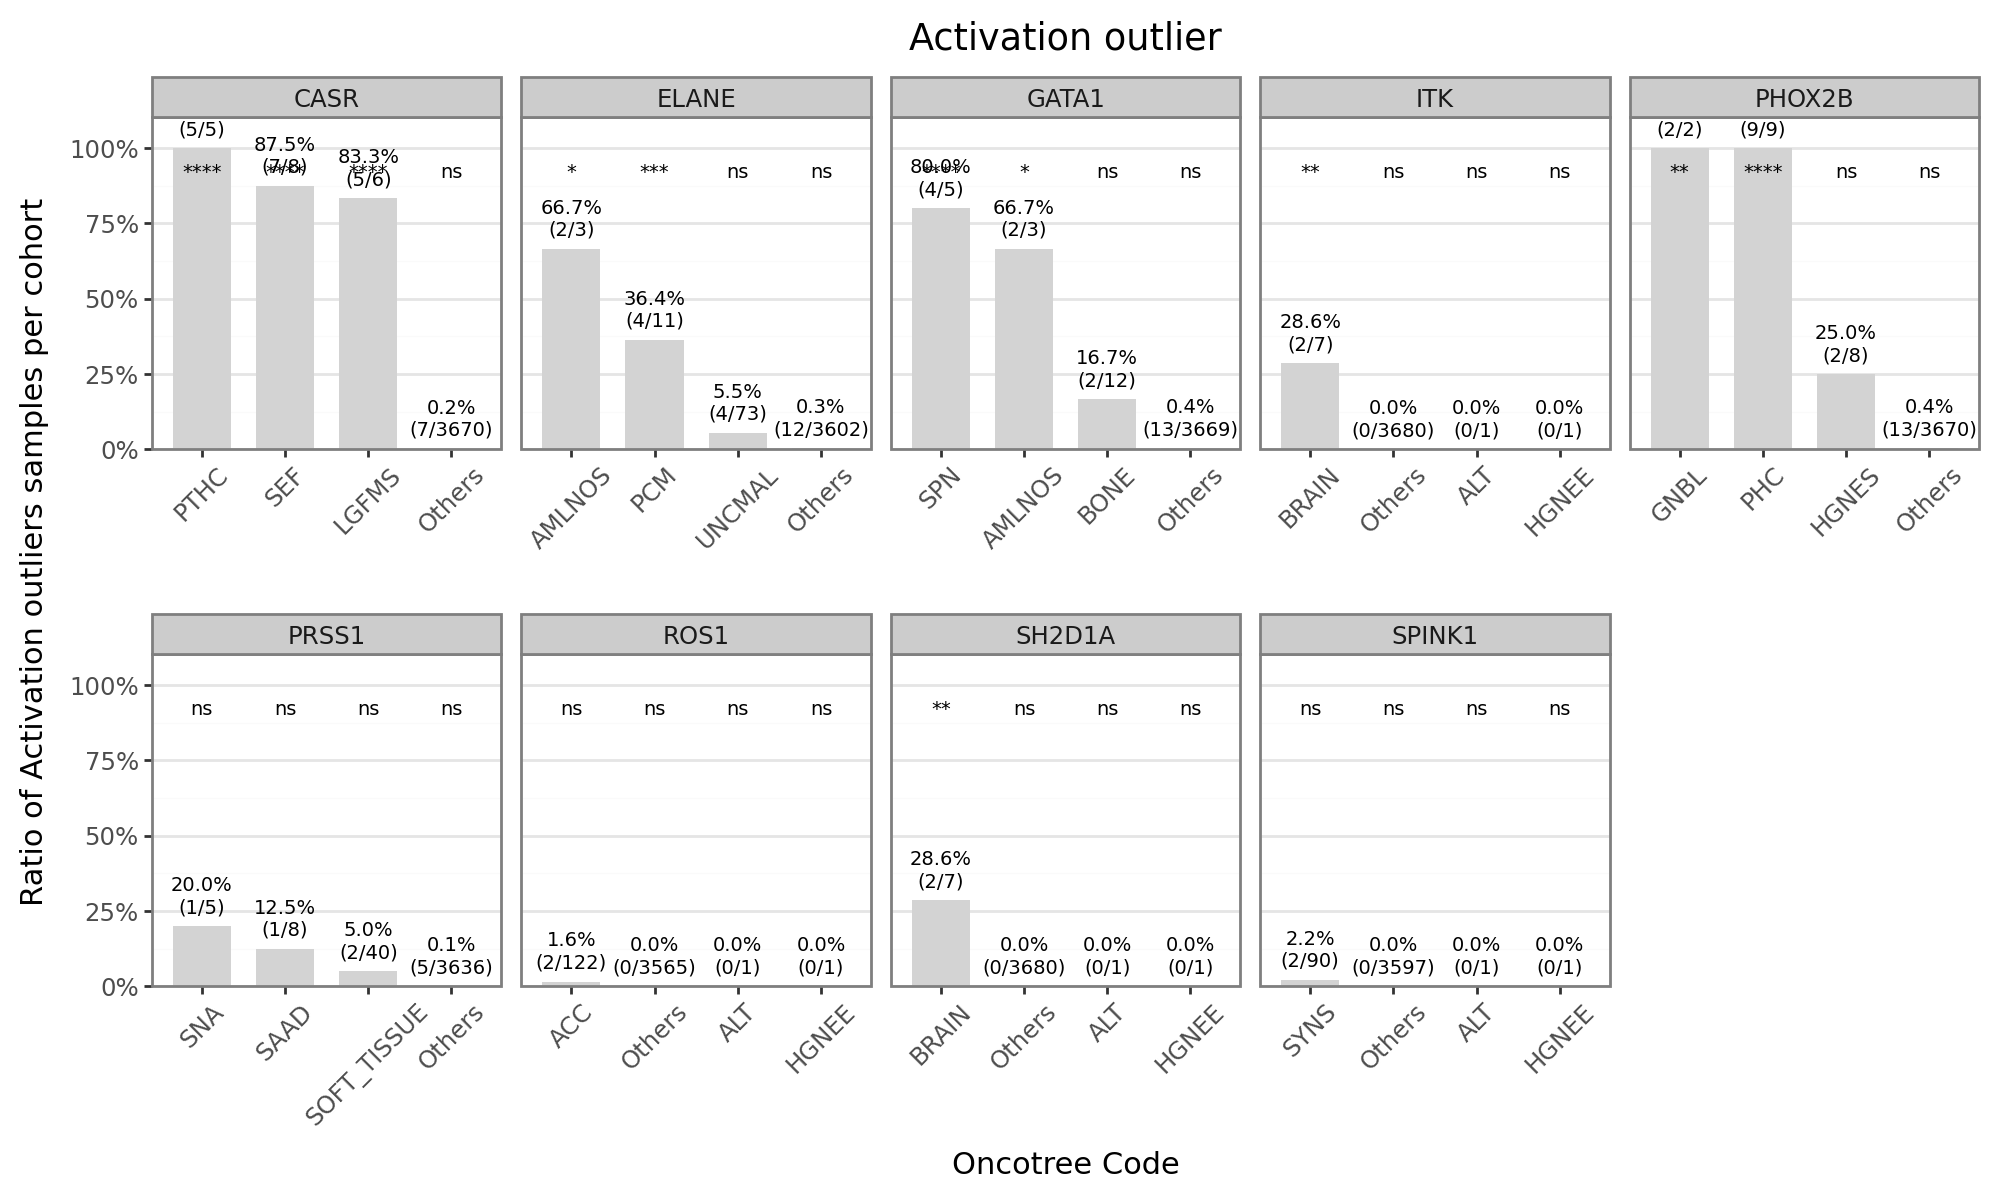

In [455]:
plot_dt = create_proportions_per_entity(activation_res, ["PHOX2B", "CASR", "ELANE", "GATA1", "ROS1", "SPINK1", "PRSS1", "SH2D1A", "ITK"],
                                        "Splicing", id_col="geneID", keep_sig=False, sa=rna_sa[rna_sa["Diag"] != "Unstranded_data"])
# Ensure the order is preserved (Top 1, 2, 3, then Others)
plot = (
    ggplot(plot_dt, aes(x='reorder(disease, -ratio)', y='ratio'))
    + facet_wrap("gene_name", scales="free_x", nrow=2)
    + geom_col(fill="#d3d3d3", width=0.7)
    + geom_text(aes(label='top_label'), va='bottom', nudge_y=0.03, size=7)
    + geom_text(aes(label='stars'), y=0.92, size=7)
    + scale_y_continuous(labels=lambda l: [f"{int(x*100)}%" for x in l],
                         limits=[0, 1.05],
                         expand=(0, 0, 0.05, 0)
                        )
    + labs(x="Oncotree Code", y=f"Ratio of Activation outliers samples per cohort", title=f"Activation outlier")
    + theme_bw()
    + theme(panel_grid_major_x=element_blank(), axis_text_x=element_text(rotation=45), figure_size=(10, 6))
)

plot